# M-04 Temporal Fall Detection

URFD RGB에서 사람 bbox와 M-03 COCO-17 keypoint를 생성하고, temporal fall model을 학습·평가·export하는 최종 Notebook

## 구현 범위

1. Colab·로컬 경로와 최소 package 설정
2. URFD RGB·동기화·frame label 무결성 검증
3. M-03 RTMPose-t 입력·출력 계약 재사용
4. `track_id`별 10 FPS COCO-17 keypoint sequence 생성
5. confidence mask와 temporal 파생 특징 계산
6. 2초·3초 window와 다중 target 생성
7. 원본 sequence 단위 train·validation·test 분리
8. PyTorch `Dataset`·`DataLoader`와 학습 준비 조건 확인
9. 전체 URFD sequence의 bbox·pose cache 생성
10. GRU temporal model 학습과 validation threshold 선택
11. test 평가, checkpoint·ONNX export와 최종 추론 확인

처음 실행할 때는 위에서 아래로 순서대로 실행한다. 원본 download와 bbox·pose 추론은 sequence별 cache를 남기므로 중단 후 같은 셀을 다시 실행해 이어갈 수 있다.

# 1. 환경 설정

Colab과 로컬 Jupyter에서 동일한 project root를 찾고, Git에서 제외되는 raw·processed dataset 경로를 준비

In [3]:
import importlib.util
import os
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from google.colab import drive

    DRIVE_MOUNT_POINT = Path("/content/drive")
    drive.mount(str(DRIVE_MOUNT_POINT))
    PROJECT_ROOT = (
        DRIVE_MOUNT_POINT / "MyDrive" / "Colab Notebooks" / "wardy-pose-fall"
    )
    runtime_name = "Google Colab"
else:
    def find_project_root(start_path: Path) -> Path:
        for candidate in (start_path, *start_path.parents):
            if (candidate / ".git").exists() and (candidate / "ml" / "notebook").is_dir():
                return candidate
        raise FileNotFoundError(
            "wardy 저장소 내부에서 Jupyter 실행 또는 WARDY_PROJECT_ROOT 설정 필요"
        )

    search_start = Path(
        os.environ.get("WARDY_PROJECT_ROOT", Path.cwd())
    ).expanduser().resolve()
    PROJECT_ROOT = find_project_root(search_start)
    runtime_name = "Local Jupyter"

REQUIREMENTS_PATH = PROJECT_ROOT / "ml" / "requirements" / "m04.txt"
RAW_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed" / "m04"
POSE_MODEL_DIR = PROJECT_ROOT / "ml" / "checkpoints" / "rtmpose-t-onnx"

# source와 분리된 cache·dataset directory를 한 번에 준비
for directory in (RAW_DATA_DIR, PROCESSED_DATA_DIR, POSE_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Runtime: {runtime_name}")
print(f"Project repository: {PROJECT_ROOT.name}")
print(f"Requirements: {REQUIREMENTS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Raw dataset directory: {RAW_DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Processed dataset directory: {PROCESSED_DATA_DIR.relative_to(PROJECT_ROOT)}")

Runtime: Local Jupyter
Project repository: wardy-pose-fall
Requirements: ml/requirements/m04.txt
Raw dataset directory: ml/data/raw
Processed dataset directory: ml/data/processed/m04


## 최소 package 설치

M-03 ONNX 추론 package에 bbox baseline, temporal 학습, ONNX export package를 추가

In [4]:
# 현재 Jupyter kernel에 M-04 최소 의존성을 설치
%pip install --quiet --disable-pip-version-check -r {REQUIREMENTS_PATH}

Note: you may need to restart the kernel to use updated packages.


## 실행 환경 확인

RTMPose는 ONNX Runtime provider를 사용하고, 이후 temporal model 학습 device는 PyTorch에서 별도로 선택

In [5]:
import platform
import sys
from importlib.metadata import version

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch

# ONNX pose inference와 PyTorch temporal training의 device를 독립적으로 선택
available_providers = ort.get_available_providers()
if torch.cuda.is_available() and "CUDAExecutionProvider" in available_providers:
    POSE_PROVIDERS = ["CUDAExecutionProvider", "CPUExecutionProvider"]
elif platform.system() == "Darwin" and "CoreMLExecutionProvider" in available_providers:
    POSE_PROVIDERS = ["CoreMLExecutionProvider", "CPUExecutionProvider"]
else:
    POSE_PROVIDERS = ["CPUExecutionProvider"]

if torch.cuda.is_available():
    TEMPORAL_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TEMPORAL_DEVICE = torch.device("mps")
else:
    TEMPORAL_DEVICE = torch.device("cpu")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()} ({platform.machine()})")
print(f"NumPy/OpenCV: {np.__version__}/{cv2.__version__}")
print(f"ONNX Runtime: {version('onnxruntime')}")
print(f"Pose providers: {POSE_PROVIDERS}")
print(f"PyTorch: {torch.__version__}")
print(f"Temporal device: {TEMPORAL_DEVICE}")

Python: 3.10.20
Platform: macOS-26.5.2-arm64-arm-64bit (arm64)
NumPy/OpenCV: 1.26.4/4.11.0
ONNX Runtime: 1.23.2
Pose providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
PyTorch: 2.2.2
Temporal device: mps


# 2. URFD sample과 label 계약

## URFD RGB sample 다운로드

공식 출처: https://fenix.ur.edu.pl/~mkepski/ds/uf.html

정면 camera `fall-01-cam0-rgb.zip`, 동기화 시각과 공식 frame label을 내려받아 하나의 sequence 계약으로 검증

In [6]:
import hashlib
from tempfile import NamedTemporaryFile
from urllib.request import urlretrieve
from zipfile import BadZipFile, ZipFile

URFD_DIR = RAW_DATA_DIR / "urfd"
URFD_BASE_URL = "https://fenix.ur.edu.pl/~mkepski/ds/data"
SAMPLE_ARCHIVE = URFD_DIR / "fall-01-cam0-rgb.zip"
FALL_LABELS_PATH = URFD_DIR / "urfall-cam0-falls.csv"
SAMPLE_SYNC_PATH = URFD_DIR / "fall-01-data.csv"
SAMPLE_SHA256 = "e5ff96108d322d7fe5ba6871a4c50d9c26c59e74abea03d2b69b6be56521736f"
FALL_LABELS_SHA256 = "4ed29af7040098ba0150d1030eeadd97bbfde5c3a4fb9b07df786d673e22a65c"
SAMPLE_SYNC_SHA256 = "60e156223725e401155b4fd25a672c498ed5b4e17897337c6971d90041818bcc"

URFD_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# 중단된 download를 cache로 오인하지 않도록 임시 파일을 검증한 뒤 교체
def download_verified(url: str, destination: Path, expected_sha256: str) -> str:
    if destination.exists() and sha256(destination) == expected_sha256:
        return "cached"

    with NamedTemporaryFile(dir=destination.parent, suffix=".part", delete=False) as file:
        partial_path = Path(file.name)
    try:
        urlretrieve(url, partial_path)
        downloaded_hash = sha256(partial_path)
        if downloaded_hash != expected_sha256:
            raise RuntimeError(f"SHA-256 mismatch for {destination.name}: {downloaded_hash}")
        partial_path.replace(destination)
    finally:
        partial_path.unlink(missing_ok=True)
    return "downloaded"

print("Verified download helper: ready")

Verified download helper: ready


In [7]:
# RGB·전체 fall label·fall-01 timestamp를 각각 고정 hash로 확보
download_states = {
    "rgb": download_verified(
        f"{URFD_BASE_URL}/{SAMPLE_ARCHIVE.name}", SAMPLE_ARCHIVE, SAMPLE_SHA256
    ),
    "labels": download_verified(
        f"{URFD_BASE_URL}/{FALL_LABELS_PATH.name}", FALL_LABELS_PATH, FALL_LABELS_SHA256
    ),
    "sync": download_verified(
        f"{URFD_BASE_URL}/{SAMPLE_SYNC_PATH.name}", SAMPLE_SYNC_PATH, SAMPLE_SYNC_SHA256
    ),
}

print(f"Download states: {download_states}")

Download states: {'rgb': 'cached', 'labels': 'cached', 'sync': 'cached'}


In [8]:
# file hash 다음에는 ZIP 내부 member까지 열어 실제 frame 손상을 검사
with ZipFile(SAMPLE_ARCHIVE) as archive:
    bad_member = archive.testzip()
    if bad_member is not None:
        raise ValueError(f"Corrupted ZIP member: {bad_member}")
    png_count = sum(name.lower().endswith(".png") for name in archive.namelist())

# 재현에 필요한 path·hash·frame 수만 상대 경로로 출력
print(f"Archive: {SAMPLE_ARCHIVE.relative_to(PROJECT_ROOT)}")
print(f"Archive SHA-256: {sha256(SAMPLE_ARCHIVE)}")
print(f"Labels SHA-256: {sha256(FALL_LABELS_PATH)}")
print(f"Sync SHA-256: {sha256(SAMPLE_SYNC_PATH)}")
print(f"Size: {SAMPLE_ARCHIVE.stat().st_size / 1024**2:.2f} MiB")
print(f"PNG frames: {png_count}")

Archive: ml/data/raw/urfd/fall-01-cam0-rgb.zip
Archive SHA-256: e5ff96108d322d7fe5ba6871a4c50d9c26c59e74abea03d2b69b6be56521736f
Labels SHA-256: 4ed29af7040098ba0150d1030eeadd97bbfde5c3a4fb9b07df786d673e22a65c
Sync SHA-256: 60e156223725e401155b4fd25a672c498ed5b4e17897337c6971d90041818bcc
Size: 55.05 MiB
PNG frames: 160


## frame·timestamp·label 정렬

공식 label `-1`은 눕지 않음, `0`은 낙상 전이, `1`은 바닥에 누운 상태이며 RGB frame 번호와 동기화 timestamp를 같은 row로 결합

In [9]:
import csv
from collections import Counter

# fall-01에 해당하는 공식 posture label과 camera timestamp만 선택
with FALL_LABELS_PATH.open(newline="") as file:
    label_rows = [row for row in csv.reader(file) if row[0] == "fall-01"]

with SAMPLE_SYNC_PATH.open(newline="") as file:
    sync_rows = list(csv.reader(file))

with ZipFile(SAMPLE_ARCHIVE) as archive:
    frame_names = sorted(name for name in archive.namelist() if name.lower().endswith(".png"))

frame_numbers = np.asarray([int(Path(name).stem.rsplit("-", 1)[1]) for name in frame_names])
label_by_frame = {int(row[1]): int(row[2]) for row in label_rows}
timestamp_by_frame = {int(row[0]): int(row[1]) for row in sync_rows}
expected_frames = np.arange(1, len(frame_names) + 1)

assert np.array_equal(frame_numbers, expected_frames)
assert set(frame_numbers) == set(label_by_frame) == set(timestamp_by_frame)

official_labels = np.asarray([label_by_frame[number] for number in frame_numbers], dtype=np.int8)
timestamps_ms = np.asarray([timestamp_by_frame[number] for number in frame_numbers], dtype=np.int64)
source_fps = 1000.0 / float(np.median(np.diff(timestamps_ms)))
label_transitions = [
    (int(frame_numbers[index]), int(official_labels[index]))
    for index in range(len(official_labels))
    if index == 0 or official_labels[index] != official_labels[index - 1]
]

print(f"Aligned frames: {len(frame_numbers)}")
print(f"Source FPS: {source_fps:.3f}")
print(f"Label counts: {dict(sorted(Counter(official_labels.tolist()).items()))}")
print(f"Label transitions (frame, label): {label_transitions}")
print("URFD frame contract: PASS")

Aligned frames: 160
Source FPS: 30.303
Label counts: {-1: 82, 0: 30, 1: 48}
Label transitions (frame, label): [(1, -1), (83, 0), (113, 1)]
URFD frame contract: PASS


# 3. M-03 keypoint 입력 계약

M-03과 같은 RTMPose-t ONNX model·SHA-256·COCO-17 순서를 재사용한다. M-01 연결 전 smoke test는 `full_frame_fallback` bbox를 명시적으로 기록하며 최종 학습 데이터로 채택하지 않는다.

In [10]:
MODEL_URL = (
    "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/"
    "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504.zip"
)
MODEL_ARCHIVE = POSE_MODEL_DIR / "rtmpose-t.zip"
MODEL_PATH = (
    POSE_MODEL_DIR / "20230831" / "rtmpose_onnx"
    / "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504"
    / "end2end.onnx"
)
MODEL_ARCHIVE_SHA256 = "937003a70832d9cc34ea16927f504792f3133e92dda1b9c626236bbbe9e805cb"
MODEL_SHA256 = "a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f"

model_archive_state = download_verified(MODEL_URL, MODEL_ARCHIVE, MODEL_ARCHIVE_SHA256)

# 검증된 archive만 사용하고 extraction 경로가 model cache 밖으로 나가지 않게 확인
if not MODEL_PATH.exists():
    model_root = POSE_MODEL_DIR.resolve()
    with ZipFile(MODEL_ARCHIVE) as archive:
        for member in archive.infolist():
            member_path = (POSE_MODEL_DIR / member.filename).resolve()
            if member_path != model_root and model_root not in member_path.parents:
                raise ValueError(f"Unsafe model archive member: {member.filename}")
        archive.extractall(POSE_MODEL_DIR)

if sha256(MODEL_PATH) != MODEL_SHA256:
    raise RuntimeError(f"Model SHA-256 mismatch: {sha256(MODEL_PATH)}")

pose_session = ort.InferenceSession(str(MODEL_PATH), providers=POSE_PROVIDERS)
pose_input_name = pose_session.get_inputs()[0].name
pose_output_names = [output.name for output in pose_session.get_outputs()]

print(f"Model archive: {model_archive_state}")
print(f"Model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Model SHA-256: {sha256(MODEL_PATH)}")
print(f"Session providers: {pose_session.get_providers()}")
print("M-03 pose session: ready")

Model archive: cached
Model: ml/checkpoints/rtmpose-t-onnx/20230831/rtmpose_onnx/rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504/end2end.onnx
Model SHA-256: a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f
Session providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
M-03 pose session: ready


2026-08-11 15:06:12.445 Python[60198:34399831] 2026-08-11 15:06:12.445223 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 5 number of nodes in the graph: 168 number of nodes supported by CoreML: 125


In [11]:
MODEL_INPUT_SIZE = np.array([192, 256], dtype=np.float32)  # width, height
BBOX_PADDING = 1.25
IMAGE_MEAN = np.array([123.675, 116.28, 103.53], dtype=np.float32)
IMAGE_STD = np.array([58.395, 57.12, 57.375], dtype=np.float32)
SIMCC_SPLIT_RATIO = 2.0
COCO_KEYPOINT_NAMES = (
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
)

# M-03과 동일한 bbox padding·affine transform·RGB normalization
def bbox_xyxy_to_center_scale(bbox_xyxy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x1, y1, x2, y2 = bbox_xyxy.astype(np.float32)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid bbox_xyxy: {bbox_xyxy}")
    center = np.array([(x1 + x2) * 0.5, (y1 + y2) * 0.5], dtype=np.float32)
    scale = np.array([x2 - x1, y2 - y1], dtype=np.float32) * BBOX_PADDING
    aspect_ratio = float(MODEL_INPUT_SIZE[0] / MODEL_INPUT_SIZE[1])
    if scale[0] > scale[1] * aspect_ratio:
        scale[1] = scale[0] / aspect_ratio
    else:
        scale[0] = scale[1] * aspect_ratio
    return center, scale

def third_point(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    direction = a - b
    return b + np.array([-direction[1], direction[0]], dtype=np.float32)

def affine_matrix(center: np.ndarray, scale: np.ndarray) -> np.ndarray:
    dst_w, dst_h = MODEL_INPUT_SIZE
    src_direction = np.array([0.0, -0.5 * scale[0]], dtype=np.float32)
    dst_direction = np.array([0.0, -0.5 * dst_w], dtype=np.float32)
    src = np.stack([center, center + src_direction, third_point(center, center + src_direction)])
    dst_center = np.array([dst_w * 0.5, dst_h * 0.5], dtype=np.float32)
    dst = np.stack([dst_center, dst_center + dst_direction, third_point(dst_center, dst_center + dst_direction)])
    return cv2.getAffineTransform(src.astype(np.float32), dst.astype(np.float32))

print(f"COCO keypoints: {len(COCO_KEYPOINT_NAMES)}")
print(f"Pose input size: {tuple(MODEL_INPUT_SIZE.astype(int))}")
print("BBox/affine helpers: ready")

COCO keypoints: 17
Pose input size: (192, 256)
BBox/affine helpers: ready


In [12]:
# 원본 frame과 bbox를 ONNX가 받는 NCHW float32 tensor로 변환
def preprocess_pose(frame: np.ndarray, bbox_xyxy: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center, scale = bbox_xyxy_to_center_scale(bbox_xyxy)
    width, height = MODEL_INPUT_SIZE.astype(int)
    crop = cv2.warpAffine(frame, affine_matrix(center, scale), (width, height))
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB).astype(np.float32)
    tensor = np.ascontiguousarray(((crop_rgb - IMAGE_MEAN) / IMAGE_STD).transpose(2, 0, 1)[None])
    return tensor.astype(np.float32), center, scale

# 두 SimCC 축의 최대 응답을 원본 frame 좌표와 confidence로 복원
def decode_simcc(simcc_x: np.ndarray, simcc_y: np.ndarray, center: np.ndarray, scale: np.ndarray) -> np.ndarray:
    locations = np.stack([np.argmax(simcc_x, axis=-1), np.argmax(simcc_y, axis=-1)], axis=-1).astype(np.float32)
    scores = np.minimum(np.max(simcc_x, axis=-1), np.max(simcc_y, axis=-1))
    model_xy = locations / SIMCC_SPLIT_RATIO
    frame_xy = model_xy / MODEL_INPUT_SIZE * scale + center - scale * 0.5
    return np.concatenate([frame_xy, scores[..., None]], axis=-1)

print("M-03 preprocess/decode contract: ready")

M-03 preprocess/decode contract: ready


# 4. COCO-17 keypoint sequence 생성

원본 약 30 FPS sequence를 첫 baseline의 10 FPS로 sampling하고, 동일한 `track_id`에 frame·timestamp·bbox·keypoint·pose quality를 연결

In [13]:
TARGET_FPS = 10.0
TRACK_ID = 1
BBOX_STRATEGY = "full_frame_fallback"
sampling_step = max(1, int(round(source_fps / TARGET_FPS)))
sample_indices = np.arange(0, len(frame_names), sampling_step)
POSE_CACHE_PATH = PROCESSED_DATA_DIR / "fall-01_rtmpose-t_10fps_full-frame.npz"

# cache는 source·model·sampling·bbox 계약이 모두 같은 경우에만 재사용
cache_is_valid = False
if POSE_CACHE_PATH.exists():
    with np.load(POSE_CACHE_PATH, allow_pickle=False) as cache:
        cache_is_valid = (
            cache["source_sha256"].item() == SAMPLE_SHA256
            and cache["model_sha256"].item() == MODEL_SHA256
            and int(cache["sampling_step"].item()) == sampling_step
            and cache["bbox_strategy"].item() == BBOX_STRATEGY
        )

print(f"Pose cache contract valid: {cache_is_valid}")

Pose cache contract valid: True


In [14]:
# cache miss일 때만 RGB archive를 열고 sampled frame을 순서대로 pose 추론
def infer_sampled_pose_sequence() -> dict[str, np.ndarray]:
    collected_bboxes = []
    collected_keypoints = []
    collected_quality = []
    with ZipFile(SAMPLE_ARCHIVE) as archive:
        for source_index in sample_indices:
            image_bytes = np.frombuffer(archive.read(frame_names[source_index]), dtype=np.uint8)
            frame_bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
            if frame_bgr is None:
                raise RuntimeError(f"Unable to decode {frame_names[source_index]}")

            # M-01 미연결 상태를 숨기지 않고 fallback bbox를 각 frame 결과에 기록
            frame_height, frame_width = frame_bgr.shape[:2]
            bbox_xyxy = np.array([0, 0, frame_width - 1, frame_height - 1], dtype=np.float32)
            pose_tensor, bbox_center, bbox_scale = preprocess_pose(frame_bgr, bbox_xyxy)
            simcc_x, simcc_y = pose_session.run(
                pose_output_names, {pose_input_name: pose_tensor}
            )
            keypoints_xyc = decode_simcc(simcc_x, simcc_y, bbox_center, bbox_scale)[0]
            collected_bboxes.append(bbox_xyxy)
            collected_keypoints.append(keypoints_xyc)
            collected_quality.append(float(np.mean(keypoints_xyc[:, 2])))

    return {
        "frame_numbers": frame_numbers[sample_indices].astype(np.int32),
        "timestamps_ms": timestamps_ms[sample_indices].astype(np.int64),
        "bboxes_xyxy": np.asarray(collected_bboxes, dtype=np.float32),
        "keypoints_xyc": np.asarray(collected_keypoints, dtype=np.float32),
        "pose_quality": np.asarray(collected_quality, dtype=np.float32),
        "official_labels": official_labels[sample_indices].astype(np.int8),
    }

print("Sequence inference helper: ready")

Sequence inference helper: ready


In [15]:
# cache와 새 inference 결과를 동일한 key의 sequence data로 통일
if cache_is_valid:
    with np.load(POSE_CACHE_PATH, allow_pickle=False) as cache:
        sequence_data = {key: cache[key] for key in (
            "frame_numbers", "timestamps_ms", "bboxes_xyxy",
            "keypoints_xyc", "pose_quality", "official_labels",
        )}
    pose_cache_state = "cached"
else:
    sequence_data = infer_sampled_pose_sequence()

    # 새 결과에는 source·model·sampling·bbox provenance를 함께 저장
    np.savez_compressed(
        POSE_CACHE_PATH,
        source_sha256=np.asarray(SAMPLE_SHA256),
        model_sha256=np.asarray(MODEL_SHA256),
        sampling_step=np.asarray(sampling_step),
        bbox_strategy=np.asarray(BBOX_STRATEGY),
        **sequence_data,
    )
    pose_cache_state = "generated"

sequence_frame_numbers = sequence_data["frame_numbers"]
sequence_timestamps_ms = sequence_data["timestamps_ms"]
sequence_bboxes = sequence_data["bboxes_xyxy"]
sequence_keypoints = sequence_data["keypoints_xyc"]
sequence_pose_quality = sequence_data["pose_quality"]
sequence_labels = sequence_data["official_labels"]
print(f"Pose cache state: {pose_cache_state}")

Pose cache state: cached


In [16]:
# frame 수·COCO-17 shape·timestamp 단조 증가를 downstream 전제조건으로 고정
assert sequence_keypoints.shape == (len(sample_indices), 17, 3)
assert np.isfinite(sequence_keypoints).all()
assert np.all(np.diff(sequence_timestamps_ms) > 0)

effective_fps = 1000.0 / float(np.median(np.diff(sequence_timestamps_ms)))
print(f"Pose cache: {pose_cache_state}")
print(f"Cache path: {POSE_CACHE_PATH.relative_to(PROJECT_ROOT)}")
print(f"BBox strategy: {BBOX_STRATEGY}")
print(f"Sequence frames: {len(sequence_frame_numbers)} at {effective_fps:.3f} FPS")
print(f"Keypoints: {sequence_keypoints.shape}")
print(f"Mean pose quality: {sequence_pose_quality.mean():.4f}")
print("M-03 sequence tensor contract: PASS (smoke-test only)")

Pose cache: cached
Cache path: ml/data/processed/m04/fall-01_rtmpose-t_10fps_full-frame.npz
BBox strategy: full_frame_fallback
Sequence frames: 54 at 10.000 FPS
Keypoints: (54, 17, 3)
Mean pose quality: 0.1683
M-03 sequence tensor contract: PASS (smoke-test only)


# 5. confidence mask와 temporal 특징

관절 좌표를 bbox 중심·폭·높이로 정규화하고, 낮은 confidence 좌표는 mask와 함께 전달한다. 몸통 기울기·엉덩이 하강·가속도·bbox 변화·관절 이동량을 model 입력 뒤쪽에 추가한다.

In [17]:
KEYPOINT_CONFIDENCE_THRESHOLD = 0.30
timestamps_s = sequence_timestamps_ms.astype(np.float64) / 1000.0
bbox_widths = np.maximum(sequence_bboxes[:, 2] - sequence_bboxes[:, 0], 1.0)
bbox_heights = np.maximum(sequence_bboxes[:, 3] - sequence_bboxes[:, 1], 1.0)
bbox_centers = np.stack([
    (sequence_bboxes[:, 0] + sequence_bboxes[:, 2]) * 0.5,
    (sequence_bboxes[:, 1] + sequence_bboxes[:, 3]) * 0.5,
], axis=-1)

joint_confidence = sequence_keypoints[:, :, 2]
joint_mask = (joint_confidence >= KEYPOINT_CONFIDENCE_THRESHOLD).astype(np.float32)
normalized_xy = sequence_keypoints[:, :, :2].copy()
normalized_xy[:, :, 0] = (normalized_xy[:, :, 0] - bbox_centers[:, None, 0]) / bbox_widths[:, None]
normalized_xy[:, :, 1] = (normalized_xy[:, :, 1] - bbox_centers[:, None, 1]) / bbox_heights[:, None]
normalized_xy *= joint_mask[:, :, None]

# 양쪽 관절 중 보이는 쪽만 사용하고 둘 다 누락되면 뒤 단계에서 보간
def pair_center(left_index: int, right_index: int) -> tuple[np.ndarray, np.ndarray]:
    pair_mask = joint_mask[:, [left_index, right_index]]
    weights = pair_mask / np.maximum(pair_mask.sum(axis=1, keepdims=True), 1.0)
    center = (normalized_xy[:, [left_index, right_index]] * weights[:, :, None]).sum(axis=1)
    valid = pair_mask.sum(axis=1) > 0
    return center, valid

def interpolate_valid(values: np.ndarray, valid: np.ndarray) -> np.ndarray:
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) == 0:
        return np.zeros_like(values, dtype=np.float32)
    return np.interp(np.arange(len(values)), valid_indices, values[valid_indices]).astype(np.float32)

print(f"Normalized keypoints: {normalized_xy.shape}")
print(f"Confidence mask threshold: {KEYPOINT_CONFIDENCE_THRESHOLD}")

Normalized keypoints: (54, 17, 2)
Confidence mask threshold: 0.3


In [18]:
# 어깨·엉덩이 중심으로 몸통 방향과 수직 이동 특징을 계산
shoulder_center, shoulder_valid = pair_center(5, 6)
hip_center, hip_valid = pair_center(11, 12)
shoulder_y = interpolate_valid(shoulder_center[:, 1], shoulder_valid)
hip_y = interpolate_valid(hip_center[:, 1], hip_valid)
torso_dx = interpolate_valid(hip_center[:, 0] - shoulder_center[:, 0], shoulder_valid & hip_valid)
torso_dy = interpolate_valid(hip_center[:, 1] - shoulder_center[:, 1], shoulder_valid & hip_valid)
torso_tilt = np.arctan2(np.abs(torso_dx), np.maximum(np.abs(torso_dy), 1e-6)) / (np.pi / 2.0)
hip_vertical_velocity = np.gradient(hip_y, timestamps_s).astype(np.float32)
hip_vertical_acceleration = np.gradient(hip_vertical_velocity, timestamps_s).astype(np.float32)
bbox_aspect = (bbox_widths / bbox_heights).astype(np.float32)
bbox_height_ratio = (bbox_heights / bbox_heights.max()).astype(np.float32)
bbox_height_velocity = np.gradient(bbox_height_ratio, timestamps_s).astype(np.float32)
visible_ratio = joint_mask.mean(axis=1).astype(np.float32)
body_center_y = ((shoulder_y + hip_y) * 0.5).astype(np.float32)
low_posture_score = np.clip((body_center_y + 0.10) / 0.55, 0.0, 1.0).astype(np.float32)

# 인접 frame에서 동시에 보이는 관절만 사용해 평균 이동 속도를 계산
joint_delta = np.diff(normalized_xy, axis=0, prepend=normalized_xy[[0]])
joint_pair_mask = joint_mask * np.vstack([joint_mask[[0]], joint_mask[:-1]])
joint_motion = (
    np.linalg.norm(joint_delta, axis=-1) * joint_pair_mask
).sum(axis=1) / np.maximum(joint_pair_mask.sum(axis=1), 1.0)
joint_motion /= np.maximum(np.gradient(timestamps_s), 1e-6)

derived_features = np.column_stack([
    torso_tilt, shoulder_y, hip_y, hip_vertical_velocity, hip_vertical_acceleration,
    bbox_aspect, bbox_height_ratio, bbox_height_velocity, visible_ratio,
    body_center_y, low_posture_score, joint_motion,
]).astype(np.float32)
derived_feature_names = (
    "torso_tilt", "shoulder_y", "hip_y", "hip_vertical_velocity",
    "hip_vertical_acceleration", "bbox_aspect", "bbox_height_ratio",
    "bbox_height_velocity", "visible_ratio", "body_center_y",
    "low_posture_score", "joint_motion",
)

print(f"Derived feature matrix: {derived_features.shape}")
print(f"Derived features: {derived_feature_names}")

Derived feature matrix: (54, 12)
Derived features: ('torso_tilt', 'shoulder_y', 'hip_y', 'hip_vertical_velocity', 'hip_vertical_acceleration', 'bbox_aspect', 'bbox_height_ratio', 'bbox_height_velocity', 'visible_ratio', 'body_center_y', 'low_posture_score', 'joint_motion')


In [19]:
# 좌표·confidence·mask·파생 특징 순서를 temporal model 입력 계약으로 고정
feature_matrix = np.concatenate([
    normalized_xy.reshape(len(normalized_xy), -1),
    joint_confidence,
    joint_mask,
    derived_features,
], axis=1).astype(np.float32)

assert np.isfinite(feature_matrix).all()
assert feature_matrix.shape[1] == 17 * 2 + 17 + 17 + len(derived_feature_names)

print(f"Feature matrix: {feature_matrix.shape}")
print(f"Coordinate/confidence/mask/derived: 34/17/17/{len(derived_feature_names)}")
POSE_QUALITY_MINIMUM = 0.30
VISIBLE_RATIO_MINIMUM = 0.50
pose_input_quality_ready = (
    sequence_pose_quality.mean() >= POSE_QUALITY_MINIMUM
    and visible_ratio.mean() >= VISIBLE_RATIO_MINIMUM
)

print(f"Visible ratio mean/min: {visible_ratio.mean():.3f}/{visible_ratio.min():.3f}")
print(f"Pose input quality ready: {pose_input_quality_ready}")
print("Temporal feature contract: PASS")

Feature matrix: (54, 80)
Coordinate/confidence/mask/derived: 34/17/17/12
Visible ratio mean/min: 0.155/0.000
Pose input quality ready: False
Temporal feature contract: PASS


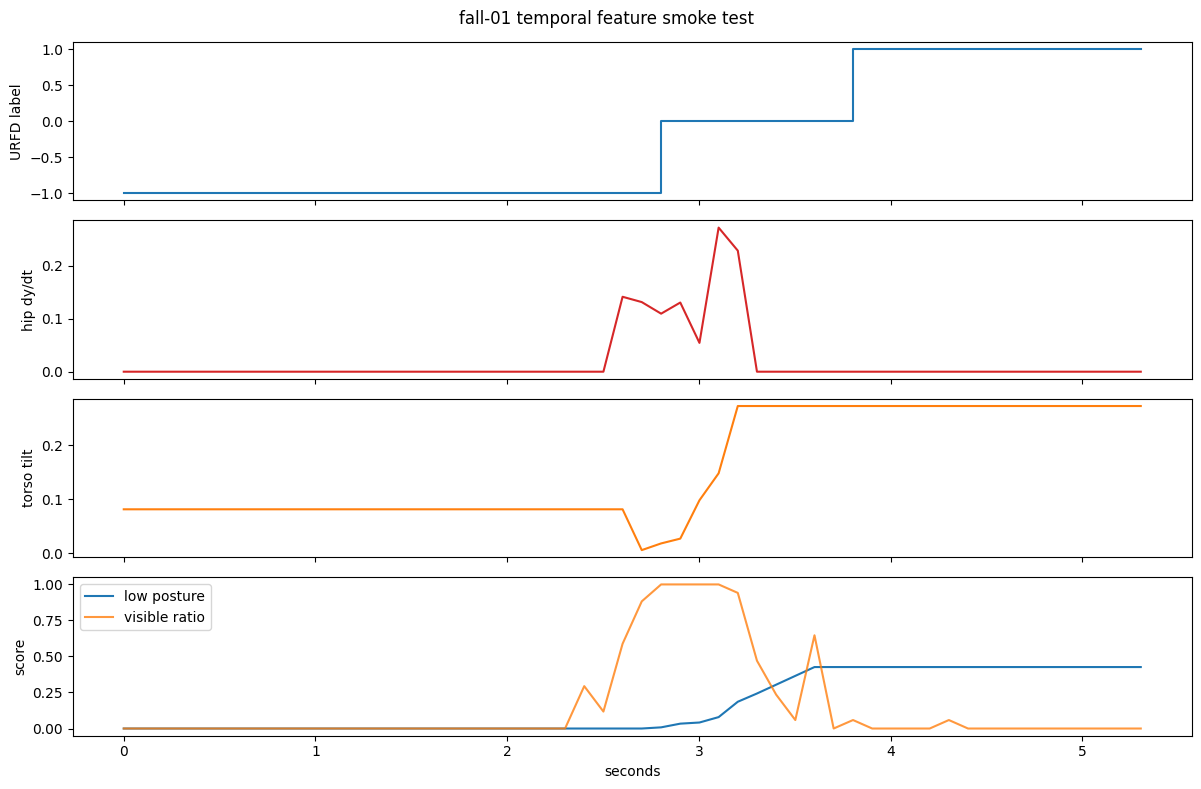

In [20]:
# label 전이와 핵심 파생 특징을 같은 시간축에서 확인
figure, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].step(timestamps_s, sequence_labels, where="post")
axes[0].set_ylabel("URFD label")
axes[1].plot(timestamps_s, hip_vertical_velocity, color="tab:red")
axes[1].set_ylabel("hip dy/dt")
axes[2].plot(timestamps_s, torso_tilt, color="tab:orange")
axes[2].set_ylabel("torso tilt")
axes[3].plot(timestamps_s, low_posture_score, label="low posture")
axes[3].plot(timestamps_s, visible_ratio, label="visible ratio", alpha=0.8)
axes[3].set_ylabel("score")
axes[3].set_xlabel("seconds")
axes[3].legend(loc="upper left")
figure.suptitle("fall-01 temporal feature smoke test")
figure.tight_layout()
plt.show()

# 6. 2초·3초 temporal window

원본 sequence를 섞기 전에 window를 만들고, 낙상 전이·낙상 이후 context·window 마지막 자세를 서로 다른 target으로 보존

In [21]:
WINDOW_SECONDS = (2.0, 3.0)
WINDOW_STRIDE_SECONDS = 0.5
TARGET_NAMES = ("fall_transition", "fall_context", "lying_at_end")

# 한 원본 sequence 안에서 시간 순서를 유지한 sliding window를 생성
def build_temporal_windows(
    features: np.ndarray,
    labels: np.ndarray,
    sequence_id: str,
    sequence_class: str,
    fps: float,
    window_seconds: float,
    stride_seconds: float = WINDOW_STRIDE_SECONDS,
) -> dict[str, np.ndarray]:
    window_size = int(round(window_seconds * fps))
    stride = max(1, int(round(stride_seconds * fps)))
    windows, targets, starts, ends = [], [], [], []

    for start in range(0, len(features) - window_size + 1, stride):
        end = start + window_size
        label_window = labels[start:end]
        is_fall_sequence = sequence_class == "fall"

        # event 전이·후속 context·마지막 자세를 별도 target으로 유지
        windows.append(features[start:end])
        targets.append([
            int(is_fall_sequence and np.any(label_window == 0)),
            int(is_fall_sequence and np.any(label_window >= 0)),
            int(label_window[-1] == 1),
        ])
        starts.append(start)
        ends.append(end - 1)

    return {
        "features": np.asarray(windows, dtype=np.float32),
        "targets": np.asarray(targets, dtype=np.int64),
        "start_indices": np.asarray(starts, dtype=np.int32),
        "end_indices": np.asarray(ends, dtype=np.int32),
        "sequence_ids": np.asarray([sequence_id] * len(windows)),
    }

print(f"Window candidates: {WINDOW_SECONDS} seconds, stride={WINDOW_STRIDE_SECONDS}s")

Window candidates: (2.0, 3.0) seconds, stride=0.5s


In [22]:
# 같은 feature sequence로 2초·3초 window shape와 target 분포를 비교
window_sets = {
    seconds: build_temporal_windows(
        feature_matrix, sequence_labels, "fall-01", "fall",
        effective_fps, seconds,
    )
    for seconds in WINDOW_SECONDS
}

for seconds, window_set in window_sets.items():
    positive_counts = dict(zip(TARGET_NAMES, window_set["targets"].sum(axis=0).tolist()))
    print(
        f"{seconds:.0f}s windows: shape={window_set['features'].shape}, "
        f"positive targets={positive_counts}"
    )

SMOKE_WINDOW_SECONDS = 2.0
SMOKE_DATA_PATH = PROCESSED_DATA_DIR / "fall-01_temporal-window-smoke.npz"
smoke_windows = window_sets[SMOKE_WINDOW_SECONDS]

# 학습 전 단계의 재실행 확인용 artifact만 ignored data path에 저장
np.savez_compressed(
    SMOKE_DATA_PATH,
    features=smoke_windows["features"],
    targets=smoke_windows["targets"],
    start_indices=smoke_windows["start_indices"],
    end_indices=smoke_windows["end_indices"],
    sequence_ids=smoke_windows["sequence_ids"],
    target_names=np.asarray(TARGET_NAMES),
    feature_count=np.asarray(feature_matrix.shape[1]),
    window_seconds=np.asarray(SMOKE_WINDOW_SECONDS),
    bbox_strategy=np.asarray(BBOX_STRATEGY),
)
print(f"Smoke artifact: {SMOKE_DATA_PATH.relative_to(PROJECT_ROOT)}")
print("Window generation: PASS")

2s windows: shape=(7, 20, 80), positive targets={'fall_transition': 5, 'fall_context': 5, 'lying_at_end': 3}
3s windows: shape=(5, 30, 80), positive targets={'fall_transition': 5, 'fall_context': 5, 'lying_at_end': 3}
Smoke artifact: ml/data/processed/m04/fall-01_temporal-window-smoke.npz
Window generation: PASS


# 7. 규칙 기반 낙상 판단 smoke baseline

`lying` 단독 판단과 하강·몸통 기울기·낮은 자세 지속·회복·관절 품질을 결합한 판단을 같은 2초 window에서 비교한다. 단일 `fall-01`과 fallback bbox 결과이므로 metric은 구현 검증용이며 모델 채택 근거가 아니다.

In [23]:
RULE_THRESHOLDS = {
    "descent_velocity": 0.20,
    "torso_tilt": 0.35,
    "low_posture": 0.55,
    "recovery": 0.25,
    "visible_ratio": 0.50,
}
derived_offset = 17 * 2 + 17 + 17
derived_index = {name: derived_offset + index for index, name in enumerate(derived_feature_names)}
rule_features = smoke_windows["features"]
tail_frames = max(1, int(round(0.5 * effective_fps)))

# 각 window를 event 판단에 필요한 소수의 설명 가능한 값으로 요약
descent_peak = rule_features[:, :, derived_index["hip_vertical_velocity"]].max(axis=1)
tilt_peak = rule_features[:, :, derived_index["torso_tilt"]].max(axis=1)
low_posture_peak = rule_features[:, :, derived_index["low_posture_score"]].max(axis=1)
low_posture_tail = rule_features[:, -tail_frames:, derived_index["low_posture_score"]].mean(axis=1)
recovery_amount = low_posture_peak - low_posture_tail
window_visible_ratio = rule_features[:, :, derived_index["visible_ratio"]].mean(axis=1)

lying_only_predictions = (low_posture_tail >= RULE_THRESHOLDS["low_posture"]).astype(np.int64)
combined_predictions = (
    (descent_peak >= RULE_THRESHOLDS["descent_velocity"])
    & (
        (tilt_peak >= RULE_THRESHOLDS["torso_tilt"])
        | (low_posture_tail >= RULE_THRESHOLDS["low_posture"])
    )
    & (recovery_amount < RULE_THRESHOLDS["recovery"])
    & (window_visible_ratio >= RULE_THRESHOLDS["visible_ratio"])
).astype(np.int64)
fall_context_target_index = TARGET_NAMES.index("fall_context")
rule_targets = smoke_windows["targets"][:, fall_context_target_index]

print(f"Rule windows: {len(rule_targets)}")
print(f"Combined positives: {int(combined_predictions.sum())}")

Rule windows: 7
Combined positives: 0


In [24]:
# 외부 metric package 없이 두 rule의 precision·recall·F1을 같은 방식으로 계산
def binary_metrics(targets: np.ndarray, predictions: np.ndarray) -> dict[str, float]:
    true_positive = int(np.sum((targets == 1) & (predictions == 1)))
    false_positive = int(np.sum((targets == 0) & (predictions == 1)))
    false_negative = int(np.sum((targets == 1) & (predictions == 0)))
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)
    return {"precision": precision, "recall": recall, "f1": f1}

rule_metric_rows = {
    "lying_only": binary_metrics(rule_targets, lying_only_predictions),
    "combined": binary_metrics(rule_targets, combined_predictions),
}
for rule_name, metrics in rule_metric_rows.items():
    print(
        f"{rule_name:>12}: precision={metrics['precision']:.3f}, "
        f"recall={metrics['recall']:.3f}, f1={metrics['f1']:.3f}"
    )

  lying_only: precision=0.000, recall=0.000, f1=0.000
    combined: precision=0.000, recall=0.000, f1=0.000


In [25]:
# 가장 최근 window를 공통 M-04 event 후보 형식으로 변환
latest_index = len(combined_predictions) - 1
evidence_score = float(np.mean(np.clip([
    descent_peak[latest_index] / RULE_THRESHOLDS["descent_velocity"],
    tilt_peak[latest_index] / RULE_THRESHOLDS["torso_tilt"],
    low_posture_tail[latest_index] / RULE_THRESHOLDS["low_posture"],
], 0.0, 1.0)))
quality_factor = float(np.clip(
    window_visible_ratio[latest_index] / RULE_THRESHOLDS["visible_ratio"], 0.0, 1.0
))

# 낮은 관절 품질과 recovery는 fall confidence를 직접 낮춤
recovery_factor = float(np.clip(
    1.0 - recovery_amount[latest_index] / RULE_THRESHOLDS["recovery"], 0.0, 1.0
))
rule_confidence = evidence_score * quality_factor * recovery_factor
rule_result = {
    "track_id": TRACK_ID,
    "timestamp_ms": int(sequence_timestamps_ms[smoke_windows["end_indices"][latest_index]]),
    "fall_suspected": bool(combined_predictions[latest_index]),
    "confidence": rule_confidence,
    "reason": {
        "descent_peak": float(descent_peak[latest_index]),
        "torso_tilt_peak": float(tilt_peak[latest_index]),
        "low_posture_tail": float(low_posture_tail[latest_index]),
        "recovery_amount": float(recovery_amount[latest_index]),
        "visible_ratio": float(window_visible_ratio[latest_index]),
        "quality_gate_pass": bool(
            window_visible_ratio[latest_index] >= RULE_THRESHOLDS["visible_ratio"]
        ),
    },
}
print(f"Rule output: {rule_result}")
print("Rule baseline contract: PASS (smoke-test metric only)")

Rule output: {'track_id': 1, 'timestamp_ms': 4905, 'fall_suspected': False, 'confidence': 0.3807425678104234, 'reason': {'descent_peak': 0.27140897512435913, 'torso_tilt_peak': 0.2727842330932617, 'low_posture_tail': 0.42657971382141113, 'recovery_amount': 0.0, 'visible_ratio': 0.2235294133424759, 'quality_gate_pass': False}}
Rule baseline contract: PASS (smoke-test metric only)


# 8. 원본 sequence 단위 split

같은 원본 sequence에서 겹쳐 생성된 window가 서로 다른 split으로 새지 않도록 30개 fall·40개 ADL sequence ID를 먼저 분리한다. URFD는 subject ID를 제공하지 않으므로 이 baseline은 sequence group을 사용한다.

In [26]:
import json

SPLIT_SEED = "wardy-m04-v1"
SPLIT_RATIOS = (0.70, 0.15, 0.15)
catalog = [
    {"sequence_id": f"fall-{index:02d}", "sequence_class": "fall"}
    for index in range(1, 31)
] + [
    {"sequence_id": f"adl-{index:02d}", "sequence_class": "adl"}
    for index in range(1, 41)
]

# class별 sequence ID를 stable hash로 정렬한 뒤 70/15/15로 분할
def assign_group_splits(rows: list[dict[str, str]]) -> list[dict[str, str]]:
    assigned = []
    for sequence_class in sorted({row["sequence_class"] for row in rows}):
        class_rows = [row.copy() for row in rows if row["sequence_class"] == sequence_class]
        class_rows.sort(
            key=lambda row: hashlib.sha256(
                f"{SPLIT_SEED}:{row['sequence_id']}".encode()
            ).hexdigest()
        )
        train_end = int(len(class_rows) * SPLIT_RATIOS[0])
        validation_end = train_end + int(len(class_rows) * SPLIT_RATIOS[1])
        for index, row in enumerate(class_rows):
            row["split"] = (
                "train" if index < train_end
                else "validation" if index < validation_end
                else "test"
            )
            assigned.append(row)
    return sorted(assigned, key=lambda row: row["sequence_id"])

catalog = assign_group_splits(catalog)
print(f"Sequence catalog: {len(catalog)} groups")

Sequence catalog: 70 groups


In [27]:
# 같은 sequence가 여러 split에 섞이지 않는지 집합 단위로 검증
split_groups = {
    split: {row["sequence_id"] for row in catalog if row["split"] == split}
    for split in ("train", "validation", "test")
}
assert split_groups["train"].isdisjoint(split_groups["validation"])
assert split_groups["train"].isdisjoint(split_groups["test"])
assert split_groups["validation"].isdisjoint(split_groups["test"])

# 재현 가능한 결과는 이후 전체 데이터 준비 단계가 재사용하도록 manifest로 저장
split_counts = Counter((row["split"], row["sequence_class"]) for row in catalog)
SPLIT_MANIFEST_PATH = PROCESSED_DATA_DIR / "urfd_sequence_split_v1.json"
SPLIT_MANIFEST_PATH.write_text(
    json.dumps({"seed": SPLIT_SEED, "ratios": SPLIT_RATIOS, "sequences": catalog}, indent=2) + "\n"
)

for split in ("train", "validation", "test"):
    print(
        f"{split:>10}: fall={split_counts[(split, 'fall')]:2d}, "
        f"adl={split_counts[(split, 'adl')]:2d}"
    )
print(f"Split manifest: {SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print("Sequence leakage check: PASS")

     train: fall=21, adl=28
validation: fall= 4, adl= 6
      test: fall= 5, adl= 6
Split manifest: ml/data/processed/m04/urfd_sequence_split_v1.json
Sequence leakage check: PASS


# 9. PyTorch dataset와 학습 준비 확인

학습 code가 받을 tensor shape·dtype·target index를 고정하고, 현재 확보된 sequence가 실제 train·validation·test 학습을 시작하기에 충분한지 별도로 판정

In [28]:
from torch.utils.data import DataLoader, Dataset

# 실제 학습에서는 train split으로만 mean/std를 fit하고 validation·test에는 재사용
def fit_feature_standardizer(train_features: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    feature_mean = train_features.mean(axis=(0, 1), keepdims=True).astype(np.float32)
    feature_std = train_features.std(axis=(0, 1), keepdims=True).astype(np.float32)
    feature_std = np.where(feature_std < 1e-6, 1.0, feature_std).astype(np.float32)
    return feature_mean, feature_std

def standardize_features(
    features: np.ndarray, feature_mean: np.ndarray, feature_std: np.ndarray
) -> np.ndarray:
    return ((features - feature_mean) / feature_std).astype(np.float32)

smoke_feature_mean, smoke_feature_std = fit_feature_standardizer(smoke_windows["features"])
standardized_smoke_features = standardize_features(
    smoke_windows["features"], smoke_feature_mean, smoke_feature_std
)
assert np.allclose(standardized_smoke_features.mean(axis=(0, 1)), 0.0, atol=1e-4)
print("Feature standardizer: PASS (smoke fit; real fit must use train split only)")

Feature standardizer: PASS (smoke fit; real fit must use train split only)


In [29]:
# numpy window를 PyTorch가 읽을 feature/target tensor pair로 노출
class PoseWindowDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray, target_index: int = 1):
        if len(features) != len(targets):
            raise ValueError("features and targets must have the same length")
        self.features = torch.from_numpy(features.astype(np.float32, copy=False))
        self.targets = torch.from_numpy(targets[:, target_index].astype(np.int64, copy=False))

    def __len__(self) -> int:
        return len(self.features)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[index], self.targets[index]

FALL_CONTEXT_TARGET_INDEX = TARGET_NAMES.index("fall_context")
smoke_dataset = PoseWindowDataset(
    standardized_smoke_features, smoke_windows["targets"], FALL_CONTEXT_TARGET_INDEX
)
smoke_loader = DataLoader(smoke_dataset, batch_size=4, shuffle=False, num_workers=0)
batch_features, batch_targets = next(iter(smoke_loader))

assert batch_features.ndim == 3
assert batch_features.dtype == torch.float32
assert batch_targets.dtype == torch.int64
assert torch.isfinite(batch_features).all()

# 첫 batch로 shape·dtype·finite-value 계약을 학습 코드 진입 전에 확인
print(f"Dataset windows: {len(smoke_dataset)}")
print(f"Batch features: shape={tuple(batch_features.shape)}, dtype={batch_features.dtype}")
print(f"Batch targets: shape={tuple(batch_targets.shape)}, values={batch_targets.tolist()}")
print(f"Model input contract: [batch, time, feature] = {tuple(batch_features.shape)}")
print("PyTorch data contract: PASS")

Dataset windows: 7
Batch features: shape=(4, 20, 80), dtype=torch.float32
Batch targets: shape=(4,), values=[0, 0, 1, 1]
Model input contract: [batch, time, feature] = (4, 20, 80)
PyTorch data contract: PASS


In [30]:
# 실제 archive 확보 상태와 bbox 품질 gate를 학습 시작 조건으로 검사
available_archives = sorted(URFD_DIR.glob("*-cam0-rgb.zip"))
available_sequence_ids = {path.name.replace("-cam0-rgb.zip", "") for path in available_archives}
available_rows = [row for row in catalog if row["sequence_id"] in available_sequence_ids]
available_counts = Counter((row["split"], row["sequence_class"]) for row in available_rows)
readiness_reasons = []

for split in ("train", "validation", "test"):
    for sequence_class in ("fall", "adl"):
        if available_counts[(split, sequence_class)] == 0:
            readiness_reasons.append(f"missing {sequence_class} sequence in {split}")
if BBOX_STRATEGY == "full_frame_fallback":
    readiness_reasons.append("M-01 bbox or reviewed person-box manifest not connected")
if not pose_input_quality_ready:
    readiness_reasons.append(
        "pose quality/visible-joint ratio below the reviewed training gate"
    )

smoke_training_ready = len(readiness_reasons) == 0
print(f"Available RGB sequences: {len(available_rows)}/70")
print(f"Smoke-stage training ready: {smoke_training_ready}")
for reason in readiness_reasons:
    print(f"  - {reason}")
print("Smoke pipeline: PASS; continue to section 10 for full training preparation")

Available RGB sequences: 1/70
Smoke-stage training ready: False
  - missing adl sequence in train
  - missing fall sequence in validation
  - missing adl sequence in validation
  - missing fall sequence in test
  - missing adl sequence in test
  - M-01 bbox or reviewed person-box manifest not connected
  - pose quality/visible-joint ratio below the reviewed training gate
Smoke pipeline: PASS; continue to section 10 for full training preparation


# 10. 전체 URFD 학습 dataset 생성

공식 camera 0 RGB 70개 sequence를 내려받아 COCO 사전학습 SSDLite bbox와 M-03 RTMPose-t pose를 cache한다. 이 bbox provider는 M01이 완성되기 전 학습 baseline이며, 이후 동일한 `bbox_xyxy` 계약으로 교체할 수 있다.

> URFD는 CC BY-NC-SA 4.0 비상업적 학술용 dataset이다. 아래 download를 실행하면 원본 RGB archive가 로컬 또는 Google Drive에 저장된다.

In [31]:
import time
from uuid import uuid4

FULL_DATASET_DOWNLOAD = True
FULL_SEQUENCE_IDS = (
    [f"fall-{index:02d}" for index in range(1, 31)]
    + [f"adl-{index:02d}" for index in range(1, 41)]
)
ADL_LABELS_PATH = URFD_DIR / "urfall-cam0-adls.csv"
POSE_SEQUENCE_DIR = PROCESSED_DATA_DIR / "pose-sequences"
TRAINING_WINDOW_DIR = PROCESSED_DATA_DIR / "training-windows"
EXPORT_DIR = PROJECT_ROOT / "ml" / "src" / "export" / "m04_temporal_fall"

for directory in (POSE_SEQUENCE_DIR, TRAINING_WINDOW_DIR, EXPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

def sequence_paths(sequence_id: str) -> tuple[Path, Path]:
    return (
        URFD_DIR / f"{sequence_id}-cam0-rgb.zip",
        URFD_DIR / f"{sequence_id}-data.csv",
    )

print(f"Full URFD sequences: {len(FULL_SEQUENCE_IDS)}")
print(f"Pose sequence cache: {POSE_SEQUENCE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Training export: {EXPORT_DIR.relative_to(PROJECT_ROOT)}")

Full URFD sequences: 70
Pose sequence cache: ml/data/processed/m04/pose-sequences
Training export: ml/src/export/m04_temporal_fall


In [32]:
# 중단된 download가 정상 cache로 남지 않도록 임시 파일 검증 후 원자적으로 교체
def download_atomic(url: str, destination: Path, is_zip: bool = False) -> str:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        if not is_zip:
            return "cached"
        try:
            with ZipFile(destination) as archive:
                if archive.testzip() is None:
                    return "cached"
        except BadZipFile:
            pass

    temporary_path = destination.with_name(
        f".{destination.name}.{uuid4().hex}.part"
    )
    try:
        for attempt in range(1, 4):
            try:
                urlretrieve(url, temporary_path)
                break
            except Exception:
                temporary_path.unlink(missing_ok=True)
                if attempt == 3:
                    raise
                print(f"Download retry {attempt}/3: {destination.name}")
                time.sleep(2 ** attempt)
        if is_zip:
            with ZipFile(temporary_path) as archive:
                broken_member = archive.testzip()
                if broken_member is not None:
                    raise RuntimeError(f"Broken ZIP member: {broken_member}")
        temporary_path.replace(destination)
    finally:
        temporary_path.unlink(missing_ok=True)
    return "downloaded"

if FULL_DATASET_DOWNLOAD:
    download_atomic(f"{URFD_BASE_URL}/{ADL_LABELS_PATH.name}", ADL_LABELS_PATH)
    for sequence_index, sequence_id in enumerate(FULL_SEQUENCE_IDS, start=1):
        archive_path, sync_path = sequence_paths(sequence_id)
        archive_state = download_atomic(
            f"{URFD_BASE_URL}/{archive_path.name}", archive_path, is_zip=True
        )
        download_atomic(f"{URFD_BASE_URL}/{sync_path.name}", sync_path)
        print(f"[{sequence_index:02d}/70] {sequence_id}: {archive_state}")

[01/70] fall-01: cached
[02/70] fall-02: downloaded
[03/70] fall-03: downloaded
[04/70] fall-04: downloaded
[05/70] fall-05: downloaded
[06/70] fall-06: downloaded
[07/70] fall-07: downloaded
[08/70] fall-08: downloaded
[09/70] fall-09: downloaded
[10/70] fall-10: downloaded
[11/70] fall-11: downloaded
[12/70] fall-12: downloaded
[13/70] fall-13: downloaded
[14/70] fall-14: downloaded
[15/70] fall-15: downloaded
[16/70] fall-16: downloaded
[17/70] fall-17: downloaded
[18/70] fall-18: downloaded
[19/70] fall-19: downloaded
[20/70] fall-20: downloaded
[21/70] fall-21: downloaded
[22/70] fall-22: downloaded
[23/70] fall-23: downloaded
[24/70] fall-24: downloaded
[25/70] fall-25: downloaded
[26/70] fall-26: downloaded
[27/70] fall-27: downloaded
[28/70] fall-28: downloaded
[29/70] fall-29: downloaded
[30/70] fall-30: downloaded
[31/70] adl-01: downloaded
[32/70] adl-02: downloaded
[33/70] adl-03: downloaded
[34/70] adl-04: downloaded
[35/70] adl-05: downloaded
[36/70] adl-06: downloaded
[3

In [33]:
import re

# fall·ADL label CSV를 (sequence_id, frame_number) lookup으로 통합
def load_label_lookup(paths: tuple[Path, ...]) -> dict[tuple[str, int], int]:
    lookup = {}
    for path in paths:
        with path.open(newline="") as handle:
            for row in csv.reader(handle):
                lookup[(row[0], int(row[1]))] = int(row[2])
    return lookup

def load_sequence_index(sequence_id: str) -> dict[str, object]:
    archive_path, sync_path = sequence_paths(sequence_id)
    sync_rows = {}
    with sync_path.open(newline="") as handle:
        for row in csv.reader(handle):
            sync_rows[int(row[0])] = int(row[1])

    with ZipFile(archive_path) as archive:
        frame_names = {}
        for name in archive.namelist():
            match = re.search(r"(\d+)(?=\.png$)", name)
            if match:
                frame_names[int(match.group(1))] = name

    frame_numbers = np.asarray(sorted(set(sync_rows) & set(frame_names)), dtype=np.int32)
    if len(frame_numbers) == 0:
        raise RuntimeError(f"No aligned RGB frames for {sequence_id}")
    return {
        "archive_path": archive_path,
        "frame_names": frame_names,
        "frame_numbers": frame_numbers,
        "timestamps_ms": np.asarray([sync_rows[n] for n in frame_numbers], dtype=np.int64),
    }

full_label_lookup = load_label_lookup((FALL_LABELS_PATH, ADL_LABELS_PATH))
print(f"Official frame labels: {len(full_label_lookup):,}")

Official frame labels: 11,544


## 사람 bbox baseline

COCO 사전학습 SSDLite에서 `person` class만 선택한다. 탐지 실패 frame은 직전 bbox를 재사용하고, 첫 frame부터 실패한 경우에만 full-frame fallback을 기록한다.

In [34]:
from torchvision.models.detection import (
    SSDLite320_MobileNet_V3_Large_Weights,
    ssdlite320_mobilenet_v3_large,
)

BBOX_PROVIDER = "torchvision_ssdlite320_coco"
PERSON_CLASS_ID = 1
PERSON_SCORE_THRESHOLD = 0.35
DETECTION_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

person_detector = ssdlite320_mobilenet_v3_large(
    weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
).to(DETECTION_DEVICE).eval()

@torch.inference_mode()
def detect_person_bbox(frame_bgr: np.ndarray) -> tuple[np.ndarray | None, float]:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    image_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float() / 255.0
    prediction = person_detector([image_tensor.to(DETECTION_DEVICE)])[0]

    boxes = prediction["boxes"].detach().cpu().numpy()
    scores = prediction["scores"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    keep = (labels == PERSON_CLASS_ID) & (scores >= PERSON_SCORE_THRESHOLD)
    if not np.any(keep):
        return None, 0.0

    candidate_boxes = boxes[keep]
    candidate_scores = scores[keep]
    areas = np.prod(np.maximum(candidate_boxes[:, 2:] - candidate_boxes[:, :2], 1.0), axis=1)
    best_index = int(np.argmax(candidate_scores * np.sqrt(areas)))
    return candidate_boxes[best_index].astype(np.float32), float(candidate_scores[best_index])

print(f"BBox provider: {BBOX_PROVIDER} on {DETECTION_DEVICE}")

100%|██████████| 13.4M/13.4M [00:00<00:00, 33.6MB/s]

BBox provider: torchvision_ssdlite320_coco on cpu


In [35]:
# timestamp 기준 sampling으로 camera FPS 차이를 10 FPS 입력 계약으로 통일
def select_timeline_indices(timestamps_ms: np.ndarray, target_fps: float) -> np.ndarray:
    interval_ms = 1000.0 / target_fps
    selected = []
    next_timestamp = float(timestamps_ms[0])
    for index, timestamp in enumerate(timestamps_ms):
        if timestamp + 1e-6 >= next_timestamp:
            selected.append(index)
            next_timestamp = float(timestamp) + interval_ms
    return np.asarray(selected, dtype=np.int32)

def pose_cache_path(sequence_id: str) -> Path:
    provider_slug = BBOX_PROVIDER.replace("torchvision_", "")
    return POSE_SEQUENCE_DIR / f"{sequence_id}_rtmpose-t_10fps_{provider_slug}.npz"

def load_pose_cache(path: Path) -> dict[str, np.ndarray] | None:
    if not path.exists():
        return None
    with np.load(path, allow_pickle=False) as cache:
        if str(cache["bbox_provider"]) != BBOX_PROVIDER:
            return None
        if str(cache["model_sha256"]) != MODEL_SHA256:
            return None
        return {key: cache[key] for key in (
            "frame_numbers", "timestamps_ms", "bboxes_xyxy",
            "bbox_scores", "bbox_fallback", "keypoints_xyc",
            "pose_quality", "official_labels",
        )}

print(f"Target pose FPS: {TARGET_FPS:.1f}")

Target pose FPS: 10.0


In [36]:
def infer_full_sequence(sequence_id: str) -> dict[str, np.ndarray]:
    source = load_sequence_index(sequence_id)
    selected = select_timeline_indices(source["timestamps_ms"], TARGET_FPS)
    frame_numbers = source["frame_numbers"][selected]
    timestamps_ms = source["timestamps_ms"][selected]

    bboxes, bbox_scores, fallbacks, keypoints, qualities = [], [], [], [], []
    previous_bbox = None
    with ZipFile(source["archive_path"]) as archive:
        for frame_number in frame_numbers:
            name = source["frame_names"][int(frame_number)]
            image_bytes = np.frombuffer(archive.read(name), dtype=np.uint8)
            frame_bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
            if frame_bgr is None:
                raise RuntimeError(f"Unable to decode {sequence_id} frame {frame_number}")

            bbox_xyxy, bbox_score = detect_person_bbox(frame_bgr)
            used_fallback = bbox_xyxy is None
            if bbox_xyxy is None and previous_bbox is not None:
                bbox_xyxy = previous_bbox.copy()
            elif bbox_xyxy is None:
                height, width = frame_bgr.shape[:2]
                bbox_xyxy = np.asarray([0, 0, width - 1, height - 1], dtype=np.float32)
            else:
                previous_bbox = bbox_xyxy.copy()

            pose_tensor, center, scale = preprocess_pose(frame_bgr, bbox_xyxy)
            simcc_x, simcc_y = pose_session.run(pose_output_names, {pose_input_name: pose_tensor})
            pose = decode_simcc(simcc_x, simcc_y, center, scale)[0]
            bboxes.append(bbox_xyxy)
            bbox_scores.append(bbox_score)
            fallbacks.append(used_fallback)
            keypoints.append(pose)
            qualities.append(float(pose[:, 2].mean()))

    labels = [full_label_lookup.get((sequence_id, int(number)), -1) for number in frame_numbers]
    return {
        "frame_numbers": frame_numbers, "timestamps_ms": timestamps_ms,
        "bboxes_xyxy": np.asarray(bboxes, dtype=np.float32),
        "bbox_scores": np.asarray(bbox_scores, dtype=np.float32),
        "bbox_fallback": np.asarray(fallbacks, dtype=np.bool_),
        "keypoints_xyc": np.asarray(keypoints, dtype=np.float32),
        "pose_quality": np.asarray(qualities, dtype=np.float32),
        "official_labels": np.asarray(labels, dtype=np.int8),
    }

In [37]:
# 70개 sequence를 개별 cache로 저장해 중단 후에도 완료된 sequence를 재사용
full_pose_sequences = {}
for sequence_index, sequence_id in enumerate(FULL_SEQUENCE_IDS, start=1):
    cache_path = pose_cache_path(sequence_id)
    sequence = load_pose_cache(cache_path)
    cache_state = "cached"
    if sequence is None:
        sequence = infer_full_sequence(sequence_id)
        np.savez_compressed(
            cache_path, bbox_provider=np.asarray(BBOX_PROVIDER),
            model_sha256=np.asarray(MODEL_SHA256), target_fps=np.asarray(TARGET_FPS),
            **sequence,
        )
        cache_state = "generated"
    full_pose_sequences[sequence_id] = sequence
    print(
        f"[{sequence_index:02d}/70] {sequence_id}: {cache_state}, "
        f"frames={len(sequence['frame_numbers'])}, "
        f"pose={sequence['pose_quality'].mean():.3f}, "
        f"bbox_fallback={sequence['bbox_fallback'].mean():.3f}"
    )

print("Full pose cache generation: PASS")

[01/70] fall-01: generated, frames=54, pose=0.599, bbox_fallback=0.204
[02/70] fall-02: generated, frames=37, pose=0.639, bbox_fallback=0.000
[03/70] fall-03: generated, frames=72, pose=0.724, bbox_fallback=0.014
[04/70] fall-04: generated, frames=32, pose=0.444, bbox_fallback=0.000
[05/70] fall-05: generated, frames=51, pose=0.608, bbox_fallback=0.137
[06/70] fall-06: generated, frames=34, pose=0.636, bbox_fallback=0.000
[07/70] fall-07: generated, frames=52, pose=0.635, bbox_fallback=0.058
[08/70] fall-08: generated, frames=31, pose=0.692, bbox_fallback=0.000
[09/70] fall-09: generated, frames=62, pose=0.680, bbox_fallback=0.097
[10/70] fall-10: generated, frames=44, pose=0.519, bbox_fallback=0.000
[11/70] fall-11: generated, frames=44, pose=0.690, bbox_fallback=0.023
[12/70] fall-12: generated, frames=37, pose=0.652, bbox_fallback=0.081
[13/70] fall-13: generated, frames=29, pose=0.606, bbox_fallback=0.000
[14/70] fall-14: generated, frames=21, pose=0.585, bbox_fallback=0.000
[15/70

## 전체 sequence 특징과 window 조립

각 sequence 안에서만 보간·미분하고, window를 만든 뒤 원본 sequence split에 따라 train·validation·test로 조립한다.

In [38]:
def visible_pair_center(
    normalized_xy: np.ndarray, joint_mask: np.ndarray, left: int, right: int
) -> tuple[np.ndarray, np.ndarray]:
    pair_mask = joint_mask[:, [left, right]]
    weights = pair_mask / np.maximum(pair_mask.sum(axis=1, keepdims=True), 1.0)
    center = (normalized_xy[:, [left, right]] * weights[:, :, None]).sum(axis=1)
    return center, pair_mask.sum(axis=1) > 0

def interpolate_series(values: np.ndarray, valid: np.ndarray) -> np.ndarray:
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) == 0:
        return np.zeros_like(values, dtype=np.float32)
    return np.interp(np.arange(len(values)), valid_indices, values[valid_indices]).astype(np.float32)

def normalize_pose_sequence(sequence: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    keypoints = sequence["keypoints_xyc"]
    bboxes = sequence["bboxes_xyxy"]
    bbox_widths = np.maximum(bboxes[:, 2] - bboxes[:, 0], 1.0)
    bbox_heights = np.maximum(bboxes[:, 3] - bboxes[:, 1], 1.0)
    bbox_centers = np.column_stack(((bboxes[:, 0] + bboxes[:, 2]) / 2, (bboxes[:, 1] + bboxes[:, 3]) / 2))

    confidence = np.clip(keypoints[:, :, 2], 0.0, 1.0).astype(np.float32)
    joint_mask = (confidence >= KEYPOINT_CONFIDENCE_THRESHOLD).astype(np.float32)
    normalized_xy = keypoints[:, :, :2].copy()
    normalized_xy[:, :, 0] = (normalized_xy[:, :, 0] - bbox_centers[:, None, 0]) / bbox_widths[:, None]
    normalized_xy[:, :, 1] = (normalized_xy[:, :, 1] - bbox_centers[:, None, 1]) / bbox_heights[:, None]
    normalized_xy = np.clip(normalized_xy, -2.0, 2.0) * joint_mask[:, :, None]
    return {
        "keypoints": keypoints, "confidence": confidence, "joint_mask": joint_mask,
        "normalized_xy": normalized_xy, "bbox_widths": bbox_widths,
        "bbox_heights": bbox_heights,
        "timestamps_s": sequence["timestamps_ms"].astype(np.float64) / 1000.0,
    }

FULL_FEATURE_NAMES = tuple(
    [f"{name}_{axis}" for name in COCO_KEYPOINT_NAMES for axis in ("x", "y")]
    + [f"{name}_confidence" for name in COCO_KEYPOINT_NAMES]
    + [f"{name}_visible" for name in COCO_KEYPOINT_NAMES]
    + list(derived_feature_names)
)

In [39]:
def extract_temporal_feature_matrix(
    sequence: dict[str, np.ndarray],
) -> tuple[np.ndarray, tuple[str, ...], dict[str, float]]:
    base = normalize_pose_sequence(sequence)
    keypoints, confidence = base["keypoints"], base["confidence"]
    joint_mask, normalized_xy = base["joint_mask"], base["normalized_xy"]
    bbox_widths, bbox_heights = base["bbox_widths"], base["bbox_heights"]
    timestamps_s = base["timestamps_s"]

    shoulder, shoulder_valid = visible_pair_center(normalized_xy, joint_mask, 5, 6)
    hip, hip_valid = visible_pair_center(normalized_xy, joint_mask, 11, 12)
    shoulder_y = interpolate_series(shoulder[:, 1], shoulder_valid)
    hip_y = interpolate_series(hip[:, 1], hip_valid)
    torso_valid = shoulder_valid & hip_valid
    torso_dx = interpolate_series(hip[:, 0] - shoulder[:, 0], torso_valid)
    torso_dy = interpolate_series(hip[:, 1] - shoulder[:, 1], torso_valid)
    torso_tilt = np.arctan2(np.abs(torso_dx), np.maximum(np.abs(torso_dy), 1e-6)) / (np.pi / 2)

    hip_velocity = np.clip(np.gradient(hip_y, timestamps_s), -8.0, 8.0)
    hip_acceleration = np.clip(np.gradient(hip_velocity, timestamps_s), -32.0, 32.0)
    bbox_height_ratio = bbox_heights / np.maximum(bbox_heights.max(), 1.0)
    bbox_height_velocity = np.clip(np.gradient(bbox_height_ratio, timestamps_s), -8.0, 8.0)
    visible_ratio = joint_mask.mean(axis=1)
    body_center_y = (shoulder_y + hip_y) * 0.5
    low_posture = np.clip((body_center_y + 0.10) / 0.55, 0.0, 1.0)

    joint_delta = np.diff(normalized_xy, axis=0, prepend=normalized_xy[[0]])
    joint_pair_mask = joint_mask * np.vstack([joint_mask[[0]], joint_mask[:-1]])
    joint_motion = (np.linalg.norm(joint_delta, axis=-1) * joint_pair_mask).sum(axis=1)
    joint_motion /= np.maximum(joint_pair_mask.sum(axis=1), 1.0)
    joint_motion /= np.maximum(np.gradient(timestamps_s), 1e-6)
    joint_motion = np.clip(joint_motion, 0.0, 10.0)

    derived = np.column_stack((
        torso_tilt, shoulder_y, hip_y, hip_velocity, hip_acceleration,
        bbox_widths / bbox_heights, bbox_height_ratio, bbox_height_velocity,
        visible_ratio, body_center_y, low_posture, joint_motion,
    )).astype(np.float32)
    matrix = np.concatenate((normalized_xy.reshape(len(keypoints), -1), confidence, joint_mask, derived), axis=1)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    stats = {
        "pose_quality": float(sequence["pose_quality"].mean()),
        "visible_ratio": float(visible_ratio.mean()),
        "bbox_fallback_ratio": float(sequence["bbox_fallback"].mean()),
    }
    return matrix, FULL_FEATURE_NAMES, stats

In [40]:
# 품질이 낮은 sequence는 window 생성 전에 제외해 split별 원인과 개수를 남김
SEQUENCE_POSE_QUALITY_MIN = 0.30
SEQUENCE_VISIBLE_RATIO_MIN = 0.40
SEQUENCE_BBOX_FALLBACK_MAX = 0.20
MIN_SEQUENCE_FRAMES = int(3.0 * TARGET_FPS)

sequence_features = {}
sequence_quality = {}
excluded_sequences = {}
feature_names = None

for sequence_id, sequence in full_pose_sequences.items():
    matrix, current_feature_names, stats = extract_temporal_feature_matrix(sequence)
    feature_names = current_feature_names if feature_names is None else feature_names
    reasons = []
    if len(matrix) < MIN_SEQUENCE_FRAMES:
        reasons.append("too_few_frames")
    if stats["pose_quality"] < SEQUENCE_POSE_QUALITY_MIN:
        reasons.append("low_pose_quality")
    if stats["visible_ratio"] < SEQUENCE_VISIBLE_RATIO_MIN:
        reasons.append("low_visible_ratio")
    if stats["bbox_fallback_ratio"] > SEQUENCE_BBOX_FALLBACK_MAX:
        reasons.append("high_bbox_fallback")
    if reasons:
        excluded_sequences[sequence_id] = reasons
    else:
        sequence_features[sequence_id] = matrix
        sequence_quality[sequence_id] = stats

print(f"Usable sequences: {len(sequence_features)}/70")
for sequence_id, reasons in excluded_sequences.items():
    print(f"  excluded {sequence_id}: {', '.join(reasons)}")

Usable sequences: 33/70
  excluded fall-01: high_bbox_fallback
  excluded fall-13: too_few_frames
  excluded fall-14: too_few_frames
  excluded fall-15: too_few_frames
  excluded fall-16: too_few_frames
  excluded fall-18: too_few_frames, high_bbox_fallback
  excluded fall-19: high_bbox_fallback
  excluded fall-21: too_few_frames, high_bbox_fallback
  excluded fall-22: too_few_frames
  excluded fall-23: too_few_frames
  excluded fall-24: too_few_frames
  excluded fall-25: too_few_frames, high_bbox_fallback
  excluded fall-26: too_few_frames
  excluded fall-28: too_few_frames, high_bbox_fallback
  excluded fall-29: high_bbox_fallback
  excluded fall-30: too_few_frames, high_bbox_fallback
  excluded adl-12: high_bbox_fallback
  excluded adl-13: high_bbox_fallback
  excluded adl-15: high_bbox_fallback
  excluded adl-16: high_bbox_fallback
  excluded adl-17: high_bbox_fallback
  excluded adl-18: high_bbox_fallback
  excluded adl-19: high_bbox_fallback
  excluded adl-20: high_bbox_fallback


In [41]:
TRAINING_WINDOW_SECONDS = 2.0
TRAINING_TARGET_NAME = "fall_transition"

def build_training_windows(
    features: np.ndarray, sequence: dict[str, np.ndarray],
    sequence_id: str, sequence_class: str,
) -> dict[str, np.ndarray]:
    labels = sequence["official_labels"]
    timestamps = sequence["timestamps_ms"]
    window_size = int(round(TRAINING_WINDOW_SECONDS * TARGET_FPS))
    stride = int(round(WINDOW_STRIDE_SECONDS * TARGET_FPS))
    windows, targets, starts, ends = [], [], [], []
    transition_positions = np.flatnonzero(labels == 0)
    event_timestamp_ms = int(timestamps[transition_positions[0]]) if len(transition_positions) else -1

    for start in range(0, len(features) - window_size + 1, stride):
        end = start + window_size
        label_window = labels[start:end]
        windows.append(features[start:end])
        targets.append(int(sequence_class == "fall" and np.any(label_window == 0)))
        starts.append(timestamps[start])
        ends.append(timestamps[end - 1])

    count = len(windows)
    return {
        "features": np.asarray(windows, dtype=np.float32),
        "targets": np.asarray(targets, dtype=np.float32),
        "sequence_ids": np.asarray([sequence_id] * count),
        "sequence_classes": np.asarray([sequence_class] * count),
        "start_timestamps_ms": np.asarray(starts, dtype=np.int64),
        "end_timestamps_ms": np.asarray(ends, dtype=np.int64),
        "event_timestamps_ms": np.asarray([event_timestamp_ms] * count, dtype=np.int64),
    }

print(f"Training target: {TRAINING_TARGET_NAME}, window={TRAINING_WINDOW_SECONDS:.1f}s")

Training target: fall_transition, window=2.0s


In [42]:
def concatenate_window_parts(parts: list[dict[str, np.ndarray]]) -> dict[str, np.ndarray]:
    if not parts:
        raise RuntimeError("No window parts available")
    return {key: np.concatenate([part[key] for part in parts], axis=0) for key in parts[0]}

catalog_by_id = {row["sequence_id"]: row for row in catalog}
window_parts = {split: [] for split in ("train", "validation", "test")}
for sequence_id, features in sequence_features.items():
    row = catalog_by_id[sequence_id]
    part = build_training_windows(
        features, full_pose_sequences[sequence_id], sequence_id, row["sequence_class"]
    )
    if len(part["features"]) > 0:
        window_parts[row["split"]].append(part)

split_bundles = {split: concatenate_window_parts(parts) for split, parts in window_parts.items()}
for split, bundle in split_bundles.items():
    artifact_path = TRAINING_WINDOW_DIR / f"urfd_{split}_2s_transition_windows.npz"
    np.savez_compressed(artifact_path, feature_names=np.asarray(feature_names), **bundle)
    print(
        f"{split:>10}: windows={len(bundle['targets']):4d}, "
        f"positive={int(bundle['targets'].sum()):4d}, "
        f"sequences={len(set(bundle['sequence_ids'])):2d}"
    )

     train: windows= 160, positive=  38, sequences=24
validation: windows=  48, positive=  10, sequences= 4
      test: windows=  25, positive=   7, sequences= 5


In [43]:
# 최소 split/class coverage와 positive target을 실제 학습 시작 직전에 강제
minimum_sequences = {"train": 10, "validation": 2, "test": 2}
full_readiness_reasons = []
for split, bundle in split_bundles.items():
    for sequence_class in ("fall", "adl"):
        class_count = len(set(bundle["sequence_ids"][bundle["sequence_classes"] == sequence_class]))
        if class_count < minimum_sequences[split]:
            full_readiness_reasons.append(
                f"{split} {sequence_class}: {class_count} < {minimum_sequences[split]} sequences"
            )
    if bundle["targets"].sum() == 0:
        full_readiness_reasons.append(f"{split}: no positive fall-transition windows")

split_sequence_sets = {split: set(bundle["sequence_ids"]) for split, bundle in split_bundles.items()}
assert split_sequence_sets["train"].isdisjoint(split_sequence_sets["validation"])
assert split_sequence_sets["train"].isdisjoint(split_sequence_sets["test"])
assert split_sequence_sets["validation"].isdisjoint(split_sequence_sets["test"])

if full_readiness_reasons:
    raise RuntimeError("Training readiness failed:\n- " + "\n- ".join(full_readiness_reasons))
print("Full training readiness: PASS")

Full training readiness: PASS


# 11. Temporal GRU 학습

train split에서만 feature mean·standard deviation을 계산하고, validation F1로 early stopping한다. 모델은 실시간 window 처리에 맞춰 단방향 GRU를 사용한다.

In [44]:
# normalization 통계는 train window에서만 fit하고 다른 split에 그대로 적용
feature_mean, feature_std = fit_feature_standardizer(split_bundles["train"]["features"])
standardized_bundles = {}
for split, bundle in split_bundles.items():
    standardized_bundles[split] = {
        **bundle,
        "features": standardize_features(bundle["features"], feature_mean, feature_std),
    }

train_feature_mean = standardized_bundles["train"]["features"].mean(axis=(0, 1))
assert np.allclose(train_feature_mean, 0.0, atol=1e-4)
for split, bundle in standardized_bundles.items():
    assert np.isfinite(bundle["features"]).all(), split
print(f"Feature dimension: {len(feature_names)}")
print("Train-only feature standardization: PASS")

Feature dimension: 80
Train-only feature standardization: PASS


In [45]:
class FallWindowDataset(Dataset):
    def __init__(self, bundle: dict[str, np.ndarray]):
        self.features = torch.from_numpy(bundle["features"].astype(np.float32, copy=False))
        self.targets = torch.from_numpy(bundle["targets"].astype(np.float32, copy=False))

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[index], self.targets[index]

BATCH_SIZE = 64
loader_generator = torch.Generator().manual_seed(42)
datasets = {split: FallWindowDataset(bundle) for split, bundle in standardized_bundles.items()}
loaders = {
    split: DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=(split == "train"),
        num_workers=0, pin_memory=(TEMPORAL_DEVICE.type == "cuda"),
        generator=loader_generator if split == "train" else None,
    )
    for split, dataset in datasets.items()
}

batch_features, batch_targets = next(iter(loaders["train"]))
assert batch_features.shape[1:] == (int(TRAINING_WINDOW_SECONDS * TARGET_FPS), len(feature_names))
print(f"Training batch: {tuple(batch_features.shape)}, targets={tuple(batch_targets.shape)}")

Training batch: (64, 20, 80), targets=(64,)


In [46]:
from torch import nn

class TemporalFallGRU(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, dropout: float = 0.25):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.LayerNorm(hidden_size), nn.ReLU(),
        )
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        projected = self.input_projection(features)
        _, hidden = self.gru(projected)
        return self.classifier(hidden[-1]).squeeze(-1)

MODEL_SEED = 42
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)
MODEL_CONFIG = {"input_size": len(feature_names), "hidden_size": 64, "dropout": 0.25}
model = TemporalFallGRU(**MODEL_CONFIG).to(TEMPORAL_DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {parameter_count:,}")

TemporalFallGRU(
  (input_projection): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (gru): GRU(64, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.25, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 32,385


In [47]:
def binary_metrics(targets: np.ndarray, probabilities: np.ndarray, threshold: float) -> dict[str, float]:
    predictions = probabilities >= threshold
    truth = targets.astype(bool)
    tp = int(np.sum(predictions & truth))
    fp = int(np.sum(predictions & ~truth))
    fn = int(np.sum(~predictions & truth))
    tn = int(np.sum(~predictions & ~truth))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    accuracy = (tp + tn) / max(len(targets), 1)
    return {
        "precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn, "threshold": threshold,
    }

@torch.inference_mode()
def predict_loader(
    trained_model: nn.Module, loader: DataLoader, criterion: nn.Module | None = None,
) -> tuple[np.ndarray, np.ndarray, float]:
    trained_model.eval()
    targets, probabilities, losses = [], [], []
    for features, batch_targets in loader:
        features = features.to(TEMPORAL_DEVICE)
        batch_targets = batch_targets.to(TEMPORAL_DEVICE)
        logits = trained_model(features)
        if criterion is not None:
            losses.append(float(criterion(logits, batch_targets).item()))
        targets.append(batch_targets.cpu().numpy())
        probabilities.append(torch.sigmoid(logits).cpu().numpy())
    mean_loss = float(np.mean(losses)) if losses else float("nan")
    return np.concatenate(targets), np.concatenate(probabilities), mean_loss

In [48]:
def set_reproducible_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_one_epoch(
    trained_model: nn.Module, loader: DataLoader, criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
) -> float:
    trained_model.train()
    losses = []
    for features, targets in loader:
        features = features.to(TEMPORAL_DEVICE)
        targets = targets.to(TEMPORAL_DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = trained_model(features)
        loss = criterion(logits, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(trained_model.parameters(), max_norm=5.0)
        optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses))

TRAINING_CONFIG = {
    "seed": 42, "epochs": 50, "learning_rate": 1e-3,
    "weight_decay": 1e-4, "early_stopping_patience": 8,
}
BEST_STATE_PATH = EXPORT_DIR / "m04_temporal_gru_best_state.pt"
set_reproducible_seed(TRAINING_CONFIG["seed"])
print(f"Training config: {TRAINING_CONFIG}")

Training config: {'seed': 42, 'epochs': 50, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'early_stopping_patience': 8}


In [49]:
# class imbalance는 train target에서 계산한 positive weight로만 보정
train_targets = split_bundles["train"]["targets"]
positive_count = float(train_targets.sum())
negative_count = float(len(train_targets) - positive_count)
pos_weight = torch.tensor(negative_count / max(positive_count, 1.0), device=TEMPORAL_DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=TRAINING_CONFIG["learning_rate"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-5,
)

history = {"train_loss": [], "validation_loss": [], "validation_f1": [], "learning_rate": []}
best_validation_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(1, TRAINING_CONFIG["epochs"] + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer)
    validation_targets, validation_probabilities, validation_loss = predict_loader(
        model, loaders["validation"], criterion
    )
    validation_metrics = binary_metrics(validation_targets, validation_probabilities, 0.5)
    scheduler.step(validation_metrics["f1"])

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["validation_f1"].append(validation_metrics["f1"])
    history["learning_rate"].append(optimizer.param_groups[0]["lr"])
    print(
        f"epoch={epoch:02d} train_loss={train_loss:.4f} val_loss={validation_loss:.4f} "
        f"val_f1={validation_metrics['f1']:.4f} val_recall={validation_metrics['recall']:.4f}"
    )

    if validation_metrics["f1"] > best_validation_f1 + 1e-6:
        best_validation_f1 = validation_metrics["f1"]
        epochs_without_improvement = 0
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch}, BEST_STATE_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= TRAINING_CONFIG["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch}")
            break

best_state = torch.load(BEST_STATE_PATH, map_location=TEMPORAL_DEVICE)
model.load_state_dict(best_state["model_state_dict"])
print(f"Best validation F1: {best_validation_f1:.4f} at epoch {best_state['epoch']}")

epoch=01 train_loss=1.0601 val_loss=0.9651 val_f1=0.4516 val_recall=0.7000
epoch=02 train_loss=0.9997 val_loss=0.9284 val_f1=0.5000 val_recall=0.8000
epoch=03 train_loss=0.9271 val_loss=0.8897 val_f1=0.5000 val_recall=0.8000
epoch=04 train_loss=0.8816 val_loss=0.8507 val_f1=0.5000 val_recall=0.8000
epoch=05 train_loss=0.8367 val_loss=0.8074 val_f1=0.5455 val_recall=0.9000
epoch=06 train_loss=0.7637 val_loss=0.7611 val_f1=0.5806 val_recall=0.9000
epoch=07 train_loss=0.7024 val_loss=0.7143 val_f1=0.5806 val_recall=0.9000
epoch=08 train_loss=0.6347 val_loss=0.6650 val_f1=0.6207 val_recall=0.9000
epoch=09 train_loss=0.5764 val_loss=0.6187 val_f1=0.6207 val_recall=0.9000
epoch=10 train_loss=0.5191 val_loss=0.5703 val_f1=0.6429 val_recall=0.9000
epoch=11 train_loss=0.4508 val_loss=0.4984 val_f1=0.6923 val_recall=0.9000
epoch=12 train_loss=0.3771 val_loss=0.4360 val_f1=0.7273 val_recall=0.8000
epoch=13 train_loss=0.3370 val_loss=0.4047 val_f1=0.7273 val_recall=0.8000
epoch=14 train_loss=0.262

# 12. Validation threshold와 test 평가

decision threshold는 test를 보지 않고 validation F1로 선택한다. 최종 test에서는 window 지표와 sequence event recall, ADL 시간당 오경보를 함께 확인한다.

In [50]:
validation_targets, validation_probabilities, _ = predict_loader(model, loaders["validation"])
threshold_candidates = np.linspace(0.10, 0.90, 161)
threshold_results = [
    binary_metrics(validation_targets, validation_probabilities, float(threshold))
    for threshold in threshold_candidates
]
best_threshold_metrics = max(
    threshold_results,
    key=lambda result: (result["f1"], result["recall"], -abs(result["threshold"] - 0.5)),
)
DECISION_THRESHOLD = float(best_threshold_metrics["threshold"])
print(f"Validation-selected threshold: {DECISION_THRESHOLD:.3f}")
print(f"Validation metrics: {best_threshold_metrics}")

Validation-selected threshold: 0.500
Validation metrics: {'precision': 0.9, 'recall': 0.9, 'f1': 0.9, 'accuracy': 0.9583333333333334, 'tp': 9, 'fp': 1, 'fn': 1, 'tn': 37, 'threshold': 0.5}


In [51]:
test_targets, test_probabilities, test_loss = predict_loader(model, loaders["test"], criterion)
test_metrics = binary_metrics(test_targets, test_probabilities, DECISION_THRESHOLD)
test_metrics["loss"] = test_loss

print("Test window metrics")
for metric_name in ("loss", "precision", "recall", "f1", "accuracy"):
    print(f"  {metric_name:>9}: {test_metrics[metric_name]:.4f}")
print(
    f"  confusion: TP={test_metrics['tp']} FP={test_metrics['fp']} "
    f"FN={test_metrics['fn']} TN={test_metrics['tn']}"
)

Test window metrics
       loss: 0.0206
  precision: 1.0000
     recall: 1.0000
         f1: 1.0000
   accuracy: 1.0000
  confusion: TP=7 FP=0 FN=0 TN=18


In [52]:
def count_positive_runs(predictions: np.ndarray) -> int:
    if len(predictions) == 0:
        return 0
    return int(predictions[0]) + int(np.sum(predictions[1:] & ~predictions[:-1]))

def sequence_event_metrics(
    bundle: dict[str, np.ndarray], probabilities: np.ndarray, threshold: float,
) -> dict[str, float]:
    predictions = probabilities >= threshold
    fall_events, detected_events, latencies = 0, 0, []
    false_alarm_events, adl_duration_ms = 0, 0.0

    for sequence_id in sorted(set(bundle["sequence_ids"])):
        indices = np.flatnonzero(bundle["sequence_ids"] == sequence_id)
        order = indices[np.argsort(bundle["end_timestamps_ms"][indices])]
        sequence_predictions = predictions[order]
        sequence_class = str(bundle["sequence_classes"][order[0]])
        if sequence_class == "fall":
            positive_positions = np.flatnonzero(bundle["targets"][order] == 1)
            if len(positive_positions) == 0:
                continue
            fall_events += 1
            detected_positions = positive_positions[sequence_predictions[positive_positions]]
            if len(detected_positions):
                detected_events += 1
                reference_end = bundle["event_timestamps_ms"][order[positive_positions[0]]]
                detection_end = bundle["end_timestamps_ms"][order[detected_positions[0]]]
                latencies.append(max(0.0, (detection_end - reference_end) / 1000.0))
        else:
            false_alarm_events += count_positive_runs(sequence_predictions)
            starts = bundle["start_timestamps_ms"][order]
            ends = bundle["end_timestamps_ms"][order]
            adl_duration_ms += float(ends.max() - starts.min())

    return {
        "fall_event_recall": detected_events / max(fall_events, 1),
        "detected_fall_events": detected_events, "fall_events": fall_events,
        "median_detection_latency_s": float(np.median(latencies)) if latencies else float("nan"),
        "false_alarm_events": false_alarm_events,
        "false_alarms_per_hour": false_alarm_events / max(adl_duration_ms / 3_600_000.0, 1e-9),
    }

test_event_metrics = sequence_event_metrics(split_bundles["test"], test_probabilities, DECISION_THRESHOLD)
print(f"Test event metrics: {test_event_metrics}")

Test event metrics: {'fall_event_recall': 1.0, 'detected_fall_events': 2, 'fall_events': 2, 'median_detection_latency_s': 1.0015, 'false_alarm_events': 0, 'false_alarms_per_hour': 0.0}


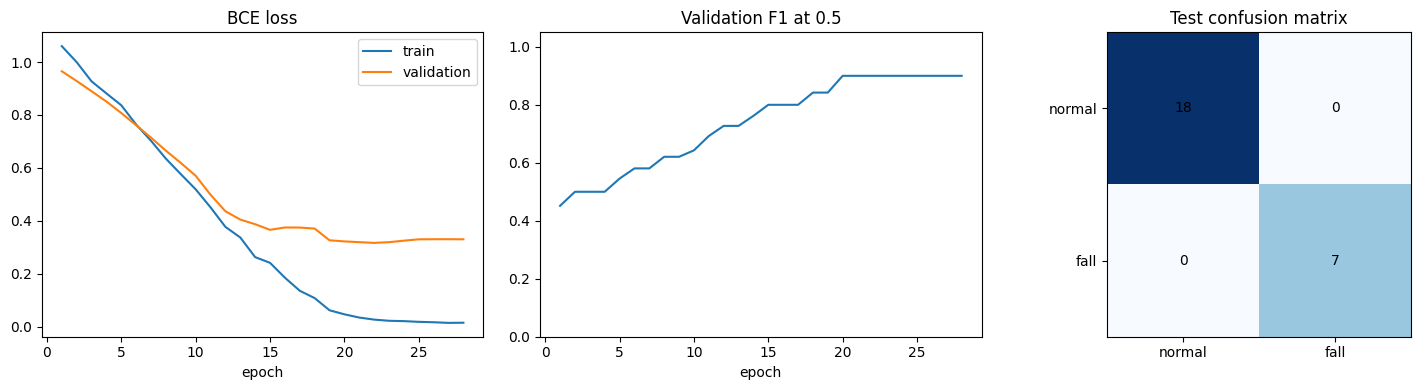

In [53]:
# 학습 곡선과 test confusion matrix를 notebook과 export directory에 함께 남김
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["validation_loss"], label="validation")
axes[0].set(title="BCE loss", xlabel="epoch")
axes[0].legend()
axes[1].plot(epochs, history["validation_f1"])
axes[1].set(title="Validation F1 at 0.5", xlabel="epoch", ylim=(0, 1.05))
confusion = np.asarray([[test_metrics["tn"], test_metrics["fp"]], [test_metrics["fn"], test_metrics["tp"]]])
axes[2].imshow(confusion, cmap="Blues")
axes[2].set(title="Test confusion matrix", xticks=(0, 1), yticks=(0, 1))
axes[2].set_xticklabels(("normal", "fall"))
axes[2].set_yticklabels(("normal", "fall"))
for row in range(2):
    for column in range(2):
        axes[2].text(column, row, int(confusion[row, column]), ha="center", va="center")
figure.tight_layout()
figure.savefig(EXPORT_DIR / "training_and_test_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

# 13. Checkpoint와 ONNX export

checkpoint에는 model weight뿐 아니라 feature 순서, train-only standardizer, window 길이와 validation threshold를 함께 저장한다. ONNX 출력은 PyTorch logit과 수치 일치를 검증한다.

In [54]:
FINAL_CHECKPOINT_PATH = EXPORT_DIR / "m04_temporal_gru.pt"
METRICS_PATH = EXPORT_DIR / "m04_test_metrics.json"

checkpoint = {
    "model_name": "TemporalFallGRU",
    "model_config": MODEL_CONFIG,
    "model_state_dict": model.state_dict(),
    "feature_names": feature_names,
    "feature_mean": feature_mean,
    "feature_std": feature_std,
    "target_name": TRAINING_TARGET_NAME,
    "target_fps": TARGET_FPS,
    "window_seconds": TRAINING_WINDOW_SECONDS,
    "decision_threshold": DECISION_THRESHOLD,
    "bbox_provider": BBOX_PROVIDER,
    "pose_model_sha256": MODEL_SHA256,
    "training_config": TRAINING_CONFIG,
    "best_epoch": int(best_state["epoch"]),
}
torch.save(checkpoint, FINAL_CHECKPOINT_PATH)

all_metrics = {"validation": best_threshold_metrics, "test_window": test_metrics, "test_event": test_event_metrics}
serializable_metrics = {
    group: {key: (value if not isinstance(value, float) or np.isfinite(value) else None) for key, value in values.items()}
    for group, values in all_metrics.items()
}
METRICS_PATH.write_text(json.dumps(serializable_metrics, indent=2, allow_nan=False) + "\n")
print(f"Final checkpoint: {FINAL_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Metrics: {METRICS_PATH.relative_to(PROJECT_ROOT)}")

Final checkpoint: ml/src/export/m04_temporal_fall/m04_temporal_gru.pt
Metrics: ml/src/export/m04_temporal_fall/m04_test_metrics.json


In [55]:
import onnx

ONNX_PATH = EXPORT_DIR / "m04_temporal_gru.onnx"
model_cpu = TemporalFallGRU(**MODEL_CONFIG).cpu().eval()
model_cpu.load_state_dict({key: value.detach().cpu() for key, value in model.state_dict().items()})
window_frames = int(round(TRAINING_WINDOW_SECONDS * TARGET_FPS))
dummy_input = torch.zeros(2, window_frames, len(feature_names), dtype=torch.float32)

torch.onnx.export(
    model_cpu, dummy_input, ONNX_PATH, input_names=["features"], output_names=["logits"],
    dynamic_axes={"features": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17, do_constant_folding=True,
)
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)

parity_input = standardized_bundles["test"]["features"][:4].astype(np.float32)
with torch.inference_mode():
    pytorch_logits = model_cpu(torch.from_numpy(parity_input)).numpy()
onnx_session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
onnx_logits = onnx_session.run(["logits"], {"features": parity_input})[0]
maximum_difference = float(np.max(np.abs(pytorch_logits - onnx_logits)))
assert maximum_difference < 1e-4
print(f"ONNX export: {ONNX_PATH.relative_to(PROJECT_ROOT)}")
print(f"PyTorch/ONNX max difference: {maximum_difference:.8f}")

ONNX export: ml/src/export/m04_temporal_fall/m04_temporal_gru.onnx
PyTorch/ONNX max difference: 0.00000095


torch.onnx: UserWarning: Exporting a GRU with dynamic batch may require explicit initial states for some batch sizes.
  warnings.warn(


In [56]:
METADATA_PATH = EXPORT_DIR / "m04_temporal_gru.metadata.json"
export_metadata = {
    "schema_version": 1,
    "model_name": "TemporalFallGRU",
    "input_name": "features", "output_name": "logits",
    "input_shape": ["batch", window_frames, len(feature_names)],
    "feature_names": list(feature_names),
    "feature_mean": feature_mean.reshape(-1).tolist(),
    "feature_std": feature_std.reshape(-1).tolist(),
    "target_name": TRAINING_TARGET_NAME,
    "target_fps": TARGET_FPS,
    "window_seconds": TRAINING_WINDOW_SECONDS,
    "decision_threshold": DECISION_THRESHOLD,
    "bbox_provider": BBOX_PROVIDER,
    "pose_model_sha256": MODEL_SHA256,
}
METADATA_PATH.write_text(json.dumps(export_metadata, indent=2) + "\n")
print(f"Export metadata: {METADATA_PATH.relative_to(PROJECT_ROOT)}")

Export metadata: ml/src/export/m04_temporal_fall/m04_temporal_gru.metadata.json


# 14. Export model 최종 추론

ONNX session이 raw temporal feature window를 train 통계로 표준화하고 Wardy event 후보 형식으로 반환하는 최종 runtime 계약을 확인한다.

In [57]:
class TemporalFallInferenceSession:
    def __init__(self, model_path: Path, metadata_path: Path):
        self.session = ort.InferenceSession(str(model_path), providers=["CPUExecutionProvider"])
        self.metadata = json.loads(metadata_path.read_text())
        self.mean = np.asarray(self.metadata["feature_mean"], dtype=np.float32)[None, None, :]
        self.std = np.asarray(self.metadata["feature_std"], dtype=np.float32)[None, None, :]
        self.threshold = float(self.metadata["decision_threshold"])
        self.expected_shape = tuple(self.metadata["input_shape"][1:])

    def predict_window(
        self, raw_features: np.ndarray, sequence_id: str, timestamp_ms: int,
    ) -> dict[str, object]:
        if raw_features.shape != self.expected_shape:
            raise ValueError(f"Expected {self.expected_shape}, received {raw_features.shape}")
        standardized = ((raw_features[None].astype(np.float32) - self.mean) / self.std).astype(np.float32)
        logit = float(self.session.run(["logits"], {"features": standardized})[0][0])
        confidence = float(1.0 / (1.0 + np.exp(-logit)))
        return {
            "sequence_id": sequence_id, "timestamp_ms": int(timestamp_ms),
            "fall_suspected": confidence >= self.threshold,
            "confidence": confidence,
            "reason": {
                "model": self.metadata["model_name"],
                "target": self.metadata["target_name"],
                "window_seconds": self.metadata["window_seconds"],
                "threshold": self.threshold,
            },
        }

fall_session = TemporalFallInferenceSession(ONNX_PATH, METADATA_PATH)
print(f"ONNX inference providers: {fall_session.session.get_providers()}")

ONNX inference providers: ['CPUExecutionProvider']


In [58]:
# held-out test의 실제 positive window를 우선 선택해 export session 입력·출력을 확인
test_bundle = split_bundles["test"]
positive_indices = np.flatnonzero(test_bundle["targets"] == 1)
sample_index = int(positive_indices[0] if len(positive_indices) else 0)
sample_event = fall_session.predict_window(
    test_bundle["features"][sample_index],
    str(test_bundle["sequence_ids"][sample_index]),
    int(test_bundle["end_timestamps_ms"][sample_index]),
)
print(json.dumps(sample_event, indent=2))
print("M-04 export inference contract: PASS")

{
  "sequence_id": "fall-02",
  "timestamp_ms": 1902,
  "fall_suspected": true,
  "confidence": 0.9926237286668598,
  "reason": {
    "model": "TemporalFallGRU",
    "target": "fall_transition",
    "window_seconds": 2.0,
    "threshold": 0.5
  }
}
M-04 export inference contract: PASS


In [59]:
def infer_pose_sequence_events(
    pose_sequence: dict[str, np.ndarray], sequence_id: str,
    inference_session: TemporalFallInferenceSession,
) -> list[dict[str, object]]:
    features, _, _ = extract_temporal_feature_matrix(pose_sequence)
    window_size = inference_session.expected_shape[0]
    stride = int(round(WINDOW_STRIDE_SECONDS * TARGET_FPS))
    events = []
    for start in range(0, len(features) - window_size + 1, stride):
        end = start + window_size
        events.append(inference_session.predict_window(
            features[start:end], sequence_id, int(pose_sequence["timestamps_ms"][end - 1])
        ))
    return events

held_out_sequence_id = str(test_bundle["sequence_ids"][sample_index])
held_out_events = infer_pose_sequence_events(
    full_pose_sequences[held_out_sequence_id], held_out_sequence_id, fall_session
)
print(f"Held-out sequence events: {len(held_out_events)}")
print(f"Suspected windows: {sum(event['fall_suspected'] for event in held_out_events)}")

Held-out sequence events: 4
Suspected windows: 4
